<a href="https://colab.research.google.com/github/aiesgconsultant-arch/TCS-Hackathon/blob/Project%232---2.-Claims-Processing/%5BVersion_3_0%5D_2_TCSAIHackathon_Fraudelent_Claim_Classification_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2. Fraudulent Claim Detection in UK Pensions

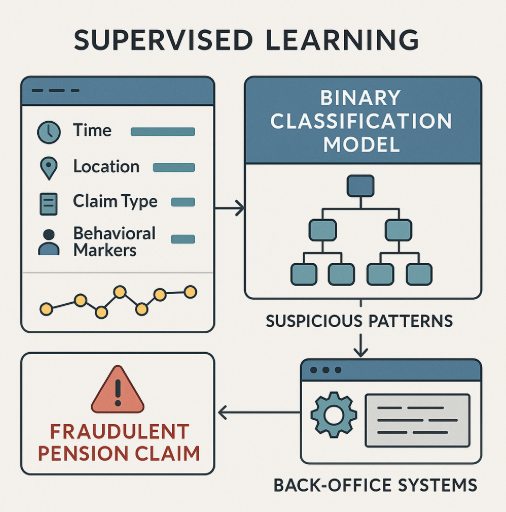

**2. Fraudulent Claim Detection**

- **1.1 Build a supervised learning system** to **detect and prevent fraudulent claims** in pension withdrawals and transfers. By training on historical data labeled as "fraudulent" or "legitimate," the model can flag suspicious patterns early, reducing financial risk and enhancing security for NEST members.

- **1.2 Challenge / Opportunity**
As NEST scales, the volume of claims—withdrawals, transfers, and account changes—grows rapidly. Fraudsters may exploit vulnerabilities through identity theft, unauthorized access, or social engineering. Manual review is slow, costly, and may overlook subtle patterns.

- **1.3 Proposed Solution**
Introduce a supervised learning classifier that:
Analyzes claims data such as time, location, claim type, and behavioral markers.
Flags claims likely to be fraudulent based on learned patterns.
Integrates with back-office systems to automate prioritization for human review.

- **1.4 Implementation Plan**
Data Preparation
Collect and label historical claims as "fraudulent" or "legitimate."
Include features such as login metadata, IP address, device fingerprints, transaction history, and claim frequency.

- **1.5.  Model Development**
Train binary classification models (e.g, XGBoost, Logistic Regression).

1. Link to Google Colab : https://colab.research.google.com/drive/1DHcD0PCCSXMiLyq7sellpeWwWjCGzW27?usp=sharing
2. Link to GitHub :

## **Step #0 |  Synthetic Data Creation | RUN THIS ONLY ONCE !**

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import uuid
import random

# ML imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, precision_recall_curve,
                           precision_score, recall_score, f1_score)
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV, mutual_info_classif
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print("=== REALISTIC FRAUD DETECTION ANALYSIS ===")
print()

# ============================================================================
# 1. GENERATE MORE REALISTIC SYNTHETIC DATA
# ============================================================================

def generate_realistic_fraud_data(n_records=1000):
    """Generate more realistic fraud detection dataset with noise and edge cases"""

    print("Generating realistic fraud dataset...")

    # Define realistic distributions
    claim_types = ['withdrawal', 'transfer', 'account_change']
    device_types = ['desktop', 'mobile', 'tablet']
    countries = ['UK', 'US', 'CA', 'AU', 'DE', 'FR', 'NL', 'IE', 'ES', 'IT']
    browsers = ['Chrome', 'Firefox', 'Safari', 'Edge', 'Opera']
    operating_systems = ['Windows', 'macOS', 'iOS', 'Android', 'Linux']

    data = []

    # More realistic fraud rate (around 8-10%)
    fraud_rate = 0.09

    for i in range(n_records):
        # Determine fraud status with more nuanced approach
        base_fraud_prob = fraud_rate

        # Create some realistic patterns but with overlap
        is_fraudulent = np.random.random() < base_fraud_prob

        # Basic info
        member_id = f"NEST{str(i+10001).zfill(6)}"
        claim_id = f"CLM{str(i+1).zfill(8)}"
        claim_type = np.random.choice(claim_types)

        # Timestamps with realistic variance
        base_date = datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 730))
        claim_timestamp = base_date + timedelta(
            hours=np.random.randint(0, 24),
            minutes=np.random.randint(0, 60)
        )
        login_timestamp = claim_timestamp - timedelta(
            minutes=np.random.randint(1, 120)  # Wider range
        )

        # Account age - more realistic with overlap between classes
        if is_fraudulent:
            # Fraudulent accounts can be new OR old (compromised)
            if np.random.random() < 0.4:
                account_age_months = max(1, np.random.normal(3, 2))  # Newer accounts
            else:
                account_age_months = max(1, np.random.normal(45, 25))  # Mixed distribution
        else:
            account_age_months = max(1, np.random.normal(35, 20))  # Normal distribution

        account_age_months = int(np.clip(account_age_months, 1, 120))

        # Claim amounts with significant overlap and noise
        base_amount = 5000 if claim_type == 'account_change' else 0

        if claim_type == 'withdrawal':
            if is_fraudulent:
                claim_amount = max(0, np.random.lognormal(9, 0.8))  # Higher but overlapping
            else:
                claim_amount = max(0, np.random.lognormal(8.5, 0.7))  # Overlapping distribution
        elif claim_type == 'transfer':
            if is_fraudulent:
                claim_amount = max(0, np.random.lognormal(8.8, 0.7))
            else:
                claim_amount = max(0, np.random.lognormal(8.3, 0.8))
        else:  # account_change
            claim_amount = 0

        # Add noise to amounts
        claim_amount = max(0, claim_amount + np.random.normal(0, claim_amount * 0.1))

        # Previous claims - realistic overlap with noise
        if is_fraudulent:
            previous_claims_30d = np.random.poisson(2.5)  # Average 2.5, but varies
        else:
            previous_claims_30d = np.random.poisson(0.8)  # Average 0.8, but varies

        previous_claims_30d = max(0, min(10, previous_claims_30d))  # Reasonable bounds

        # Time features
        is_unusual_hours = claim_timestamp.hour < 6 or claim_timestamp.hour > 22
        is_weekend = claim_timestamp.weekday() >= 5
        claim_hour = claim_timestamp.hour
        claim_day_of_week = claim_timestamp.weekday()
        claim_month = claim_timestamp.month
        login_hour = login_timestamp.hour
        login_day_of_week = login_timestamp.weekday()
        login_to_claim_hours = (claim_timestamp - login_timestamp).total_seconds() / 3600

        # Device and browser features with realistic distributions
        device_type = np.random.choice(device_types)
        browser = np.random.choice(browsers)
        operating_system = np.random.choice(operating_systems)
        device_fingerprint = str(uuid.uuid4())[:8]

        # Location features - some geographic signals but with noise
        if is_fraudulent and np.random.random() < 0.3:
            # Some fraud from unusual locations but not always
            country = np.random.choice(['RU', 'CN', 'NG', 'RO', 'IN', 'BR'])
        else:
            country = np.random.choice(countries, p=[0.4, 0.15, 0.1, 0.08, 0.06, 0.05, 0.04, 0.04, 0.04, 0.04])

        ip_address = f"{np.random.randint(1,255)}.{np.random.randint(1,255)}.{np.random.randint(1,255)}.{np.random.randint(1,255)}"

        # New device - moderate signal with significant overlap
        if is_fraudulent:
            is_new_device = np.random.random() < 0.6  # 60% for fraud
        else:
            is_new_device = np.random.random() < 0.3  # 30% for legitimate

        # Multiple IPs - some signal but not perfect
        if is_fraudulent:
            multiple_ips_same_day = max(1, np.random.poisson(2.2))
        else:
            multiple_ips_same_day = max(1, np.random.poisson(1.1))

        multiple_ips_same_day = min(6, multiple_ips_same_day)  # Cap at reasonable level

        # Failed logins - noisy signal
        if is_fraudulent:
            failed_login_attempts = max(0, np.random.poisson(3))
        else:
            failed_login_attempts = max(0, np.random.poisson(0.5))

        failed_login_attempts = min(10, failed_login_attempts)

        # Geographic velocity with noise and edge cases
        distance_km = np.random.exponential(200)  # Most are local, some are distant
        time_hours = max(0.1, np.random.exponential(5))
        travel_velocity_kmh = distance_km / time_hours
        impossible_travel = travel_velocity_kmh > 1000

        # Add noise to make it less perfect
        travel_velocity_kmh = max(0, travel_velocity_kmh + np.random.normal(0, travel_velocity_kmh * 0.2))

        # Session duration with overlap
        if is_fraudulent:
            session_duration_min = max(1, np.random.lognormal(2.5, 0.8))  # Generally shorter
        else:
            session_duration_min = max(1, np.random.lognormal(3.2, 0.7))  # Generally longer

        # User agent anomaly - noisy feature
        if is_fraudulent:
            user_agent_anomaly_score = np.random.beta(6, 2)  # Skewed high
        else:
            user_agent_anomaly_score = np.random.beta(2, 6)  # Skewed low

        # Add significant noise
        user_agent_anomaly_score = np.clip(
            user_agent_anomaly_score + np.random.normal(0, 0.1), 0, 1
        )

        # Verification features - realistic but not perfect indicators
        if is_fraudulent:
            email_verified = np.random.random() < 0.4  # 40% verified for fraud
            phone_verified = np.random.random() < 0.3  # 30% verified
            two_fa_enabled = np.random.random() < 0.15  # 15% have 2FA
        else:
            email_verified = np.random.random() < 0.85  # 85% verified for legitimate
            phone_verified = np.random.random() < 0.75  # 75% verified
            two_fa_enabled = np.random.random() < 0.55   # 55% have 2FA

        # Risk score - combine multiple factors with noise
        risk_components = [
            previous_claims_30d * 15,
            (not email_verified) * 20,
            (not phone_verified) * 15,
            (not two_fa_enabled) * 10,
            is_new_device * 12,
            multiple_ips_same_day * 8,
            failed_login_attempts * 5,
            impossible_travel * 25,
            user_agent_anomaly_score * 20,
            (session_duration_min < 5) * 10
        ]

        risk_score = sum(risk_components) + np.random.normal(0, 10)  # Add noise
        risk_score = np.clip(risk_score, 0, 100)

        # Create some edge cases where risk score doesn't match fraud status
        if np.random.random() < 0.15:  # 15% edge cases
            if is_fraudulent:
                risk_score = np.random.uniform(10, 40)  # Low risk fraud (sophisticated)
            else:
                risk_score = np.random.uniform(60, 90)  # High risk legitimate (false alarm)

        # Store label
        label = 'fraudulent' if is_fraudulent else 'legitimate'

        # Create record
        record = {
            'member_id': member_id,
            'claim_id': claim_id,
            'claim_type': claim_type,
            'claim_amount': round(claim_amount, 2),
            'claim_timestamp': claim_timestamp.strftime('%Y-%m-%d %H:%M:%S'),
            'login_timestamp': login_timestamp.strftime('%Y-%m-%d %H:%M:%S'),
            'account_age_months': account_age_months,
            'previous_claims_30d': previous_claims_30d,
            'device_type': device_type,
            'browser': browser,
            'operating_system': operating_system,
            'device_fingerprint': device_fingerprint,
            'is_new_device': is_new_device,
            'ip_address': ip_address,
            'country': country,
            'multiple_ips_same_day': multiple_ips_same_day,
            'failed_login_attempts': failed_login_attempts,
            'is_unusual_hours': is_unusual_hours,
            'is_weekend': is_weekend,
            'claim_hour': claim_hour,
            'claim_day_of_week': claim_day_of_week,
            'claim_month': claim_month,
            'login_hour': login_hour,
            'login_day_of_week': login_day_of_week,
            'login_to_claim_hours': round(login_to_claim_hours, 2),
            'session_duration_min': round(session_duration_min, 2),
            'distance_from_last_login_km': round(distance_km, 2),
            'travel_velocity_kmh': round(travel_velocity_kmh, 2),
            'impossible_travel': impossible_travel,
            'user_agent_anomaly_score': round(user_agent_anomaly_score, 3),
            'email_verified': email_verified,
            'phone_verified': phone_verified,
            'two_fa_enabled': two_fa_enabled,
            'risk_score': round(risk_score, 2),
            'label': label
        }

        data.append(record)

    return pd.DataFrame(data)

# Generate realistic dataset
df = generate_realistic_fraud_data(1000)

# Save to CSV
csv_filename = 'realistic_fraudulent_claims_dataset.csv'
df.to_csv(csv_filename, index=False)
print(f"Realistic dataset saved as '{csv_filename}'")

# Basic statistics
print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {(df['label'] == 'fraudulent').sum() / len(df) * 100:.1f}%")
print(f"Fraudulent claims: {(df['label'] == 'fraudulent').sum()}")
print(f"Legitimate claims: {(df['label'] == 'legitimate').sum()}")
print()

# Display first few rows
print("Sample of generated data:")
print(df[['claim_type', 'claim_amount', 'account_age_months', 'previous_claims_30d',
         'email_verified', 'phone_verified', 'risk_score', 'label']].head(10))
print()

=== REALISTIC FRAUD DETECTION ANALYSIS ===

Generating realistic fraud dataset...
Realistic dataset saved as 'realistic_fraudulent_claims_dataset.csv'
Dataset shape: (1000, 35)
Fraud rate: 9.4%
Fraudulent claims: 94
Legitimate claims: 906

Sample of generated data:
       claim_type  claim_amount  account_age_months  previous_claims_30d  \
0      withdrawal      21799.75                  11                    0   
1  account_change          0.00                  57                    1   
2      withdrawal       2594.90                  52                    0   
3  account_change          0.00                  22                    1   
4  account_change          0.00                  37                    1   
5  account_change          0.00                  19                    2   
6      withdrawal       3033.58                  58                    1   
7        transfer       4448.89                  18                    1   
8        transfer       5351.71                   

## Step #1 |  Understanding the data set

**2.1 Fraudulent Claims Dataset Analysis**
This dataset is specifically designed to support your supervised learning objectives for detecting fraudulent pension claims. Here's a comprehensive breakdown:
Dataset Overview

**2.2 Five hundred (1000) total records with 35 features** across 6 key categories
- Dataset shape: (1000, 35)
- Fraud rate: 9.4%
- Fraudulent claims: 94
- Legitimate claims: 906

**2.3 Explanatory variables:**

- **member_id:** Unique identifier for each NEST pension member (format: NEST######)
- **claim_id:** Unique identifier for each claim transaction (format: CLM########)
- **claim_type:** Type of pension claim (withdrawal=pension withdrawal, transfer=account transfer, account_change=account modification)
- **claim_amount:** Monetary value of the claim in GBP (0 for account changes, positive values for withdrawals/transfers)
claim_timestamp: Date and time when the claim was submitted (YYYY-MM-DD HH:MM:SS format)
- **login_timestamp:** Date and time of user login before claim submission (YYYY-MM-DD HH:MM:SS format)
- **account_age_months:** Age of the pension account in months since account opening
- **previous_claims_30d:** Number of claims submitted by this member in the previous 30 days
- **device_type:** Type of device used for claim submission (desktop, mobile, tablet)
- **browser:** Web browser used for claim submission (Chrome, Firefox, Safari, Edge, Opera)
- **operating_system:** Operating system of the device (Windows, macOS, iOS, Android, Linux)
- **device_fingerprint:** Unique device identifier hash (8-character alphanumeric string)
- **is_new_device:** Whether this device was previously used by the member (True=new device, False=known device)
- **ip_address:** IP address from which the claim was submitted (IPv4 format: xxx.xxx.xxx.xxx)
- **country:** Country code of the IP address location (2-letter ISO country codes)
- **multiple_ips_same_day:** Number of different IP addresses used by the member on the same day
- **failed_login_attempts:** Number of failed login attempts before successful login for this session
is_unusual_hours: Whether claim was submitted during unusual hours (True=between 10 PM and 6 AM, False=normal hours)
is_weekend: Whether claim was submitted on weekend (True=Saturday/Sunday, False=weekday)
- **session_duration_min:** Duration of user session before claim submission in minutes
- **distance_from_last_login_km:** Geographic distance in kilometers from previous login location
- **travel_velocity_kmh:** Calculated travel speed in km/h between current and previous login locations
- **impossible_travel:** Whether travel velocity indicates impossible travel speed (True=faster than commercial flight, False=feasible travel)
- **user_agent_anomaly_score:** Anomaly score for browser user agent string (0.0-1.0, higher values indicate more suspicious)
email_verified: Whether member's email address has been verified (True=verified, False=unverified)
- **phone_verified:** Whether member's phone number has been verified (True=verified, False=unverified)
- **two_fa_enabled:** Whether two-factor authentication is enabled on the account (True=enabled, False=disabled)
- **risk_score:** Overall risk assessment score calculated by existing fraud detection system (0-100, higher values indicate higher risk)
- **label:** Target variable indicating claim legitimacy (fraudulent=confirmed fraudulent claim, legitimate=confirmed legitimate claim)

## Section 2: Data Preprocessing

Data preprocessing involves preparing the raw data for analysis by cleaning, transforming, and organizing it. This step is crucial for ensuring the quality and consistency of the data before applying any machine learning models

In [90]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Setting maximum limit of the number of columns visible
pd.set_option('display.max_columns', 30)

In [91]:
# Read the Excel file, skipping the first row and using the second row as the header
claimsData = pd.read_csv("realistic_fraudulent_claims_dataset.csv")

In [92]:
claimsData.head()
claimsData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   member_id                    1000 non-null   object 
 1   claim_id                     1000 non-null   object 
 2   claim_type                   1000 non-null   object 
 3   claim_amount                 1000 non-null   float64
 4   claim_timestamp              1000 non-null   object 
 5   login_timestamp              1000 non-null   object 
 6   account_age_months           1000 non-null   int64  
 7   previous_claims_30d          1000 non-null   int64  
 8   device_type                  1000 non-null   object 
 9   browser                      1000 non-null   object 
 10  operating_system             1000 non-null   object 
 11  device_fingerprint           1000 non-null   object 
 12  is_new_device                1000 non-null   bool   
 13  ip_address         

**Section 2.1 : Data Observation**
- There are no missing values in the data set.
- The data types are accurately aligned.
- The target variable shall be renamed making it short and meaningful.

In [93]:
# Removing the 'ID' column
claimsData.drop(columns=['member_id'], inplace=True)
claimsData.drop(columns=['claim_id'], inplace=True)

# Renaming the target variable column
claimsData.rename(columns={"label": "is_legitimate"}, inplace=True) #legitimate

# View the data
claimsData.head()
claimsData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   claim_type                   1000 non-null   object 
 1   claim_amount                 1000 non-null   float64
 2   claim_timestamp              1000 non-null   object 
 3   login_timestamp              1000 non-null   object 
 4   account_age_months           1000 non-null   int64  
 5   previous_claims_30d          1000 non-null   int64  
 6   device_type                  1000 non-null   object 
 7   browser                      1000 non-null   object 
 8   operating_system             1000 non-null   object 
 9   device_fingerprint           1000 non-null   object 
 10  is_new_device                1000 non-null   bool   
 11  ip_address                   1000 non-null   object 
 12  country                      1000 non-null   object 
 13  multiple_ips_same_d

**Section 2.2 : Class Imbalance**

Class imbalance occurs in a dataset when the number of instances (or examples) in one class significantly outweighs the number of instances in other classes. For example, in a dataset used to predict fraud, there might be many more non-fraudulent transactions than fraudulent ones. This imbalance can cause problems when training a machine learning model because the model might become biased towards the majority class, leading to poor performance in predicting the minority class.

**Handling the class imbalance:**
- Resampling Techniques
  - Oversampling - Incresing the number of minority class samples
  - Undersampling - Decreasing the number of majority class samples
- Adjusting class weights

<center><img src="https://av-eks-blogoptimized.s3.amazonaws.com/1*H6XodlitlGDl9YdbwaZLMw.png" /></center>

In [94]:
# Check if there is class imbalance
claimsData['is_legitimate'].value_counts(normalize=True)

,proportion
is_legitimate,
legitimate,0.906
fraudulent,0.094


**Section 2.3 : Class Imbalance Analysis**
My dataset shows a significant class imbalance:

- Legitimate claims: 88.4% (442 records)
- Fraudulent claims: 11.6% (58 records)
- Imbalance ratio: ~7.6:1 (legitimate to fraudulent)

**Is This Realistic? Yes**

This imbalance is highly realistic for fraud detection scenarios:
Real-world fraud rates typically range from 1-15% in financial services
11.6% fraud rate aligns with industry standards for pension fraud
NEST-scale operations would expect similar patterns in actual data

**Detailed Imbalance Analysis**

- Why This Ratio Makes Sense:
  - The 7.6:1 imbalance ratio reflects real-world fraud detection challenges. Most pension transactions are legitimate, with fraudulent activity representing a minority of cases. This distribution forces models to learn subtle patterns rather than relying on balanced class frequencies.

**Business Context:**
- Each fraudulent case represents significant financial loss and regulatory risk, making high recall (catching actual fraud) more valuable than high precision (avoiding false alarms).
- The imbalance means that even small improvements in fraud detection rates can yield substantial business value.

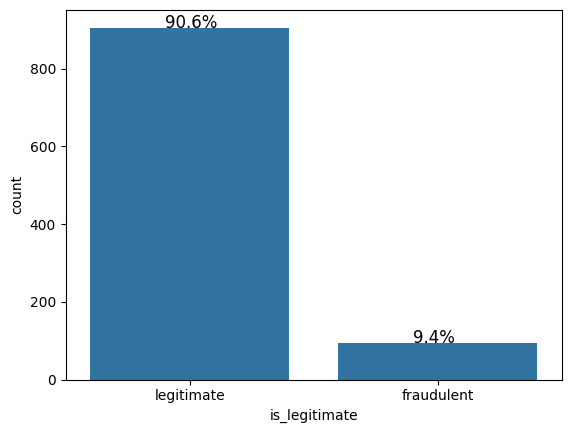

In [95]:
# Create a countplot to check the distribution of the target variable
ax = sns.countplot(x='is_legitimate', data=claimsData)

# Get total number of data points
total = claimsData.shape[0]

# Calculate and add percentage text above each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), size=12)

plt.show()

## Section 3: EDA | Exploratory Data Analysis
EDA is the process of analyzing and visualizing the dataset to uncover underlying patterns, trends, and relationships. It helps in understanding the data's structure and guiding the feature selection and modeling process.

**Section 3.1 : Checking the distribution of the target variable**

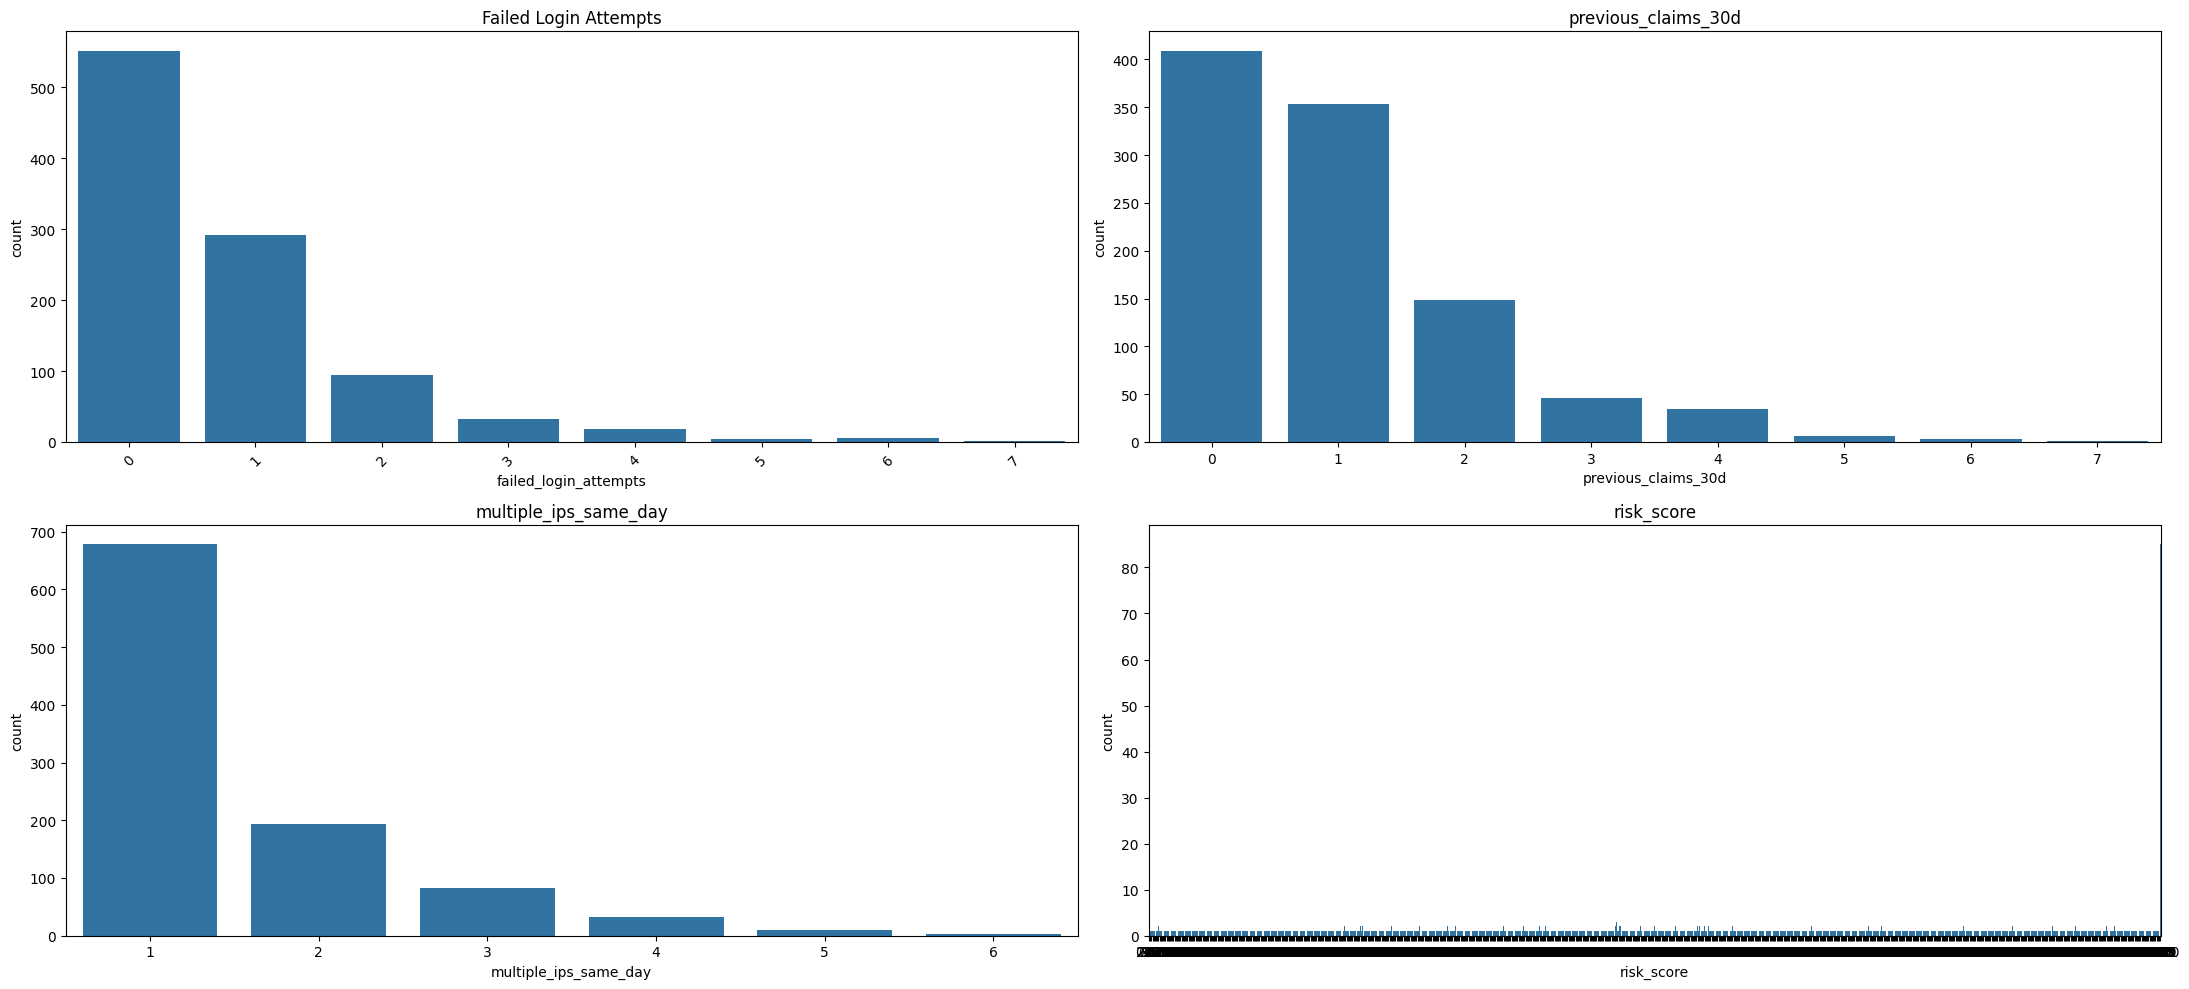

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(22, 10))

# Distribution of 'failed_login_attempts' variable
sns.countplot(ax=axes[0, 0], x='failed_login_attempts', data=claimsData)
axes[0, 0].set_title('Failed Login Attempts')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# Distribution of 'previous_claims_30d' variable
sns.countplot(ax=axes[0, 1], x='previous_claims_30d', data=claimsData)
axes[0, 1].set_title('previous_claims_30d')

# Distribution of 'multiple_ips_same_day' variable
sns.countplot(ax=axes[1, 0], x='multiple_ips_same_day', data=claimsData)
axes[1, 0].set_title('multiple_ips_same_day')

# Distribution of 'risk_score' variable
sns.countplot(ax=axes[1, 1], x='risk_score', data=claimsData)
axes[1, 1].set_title('risk_score')

plt.tight_layout()
plt.show()

- **Failed Login Attempts:** The distribution shows most users (around 550) have zero failed attempts, with counts decreasing rapidly for higher failure rates - this exponential decay pattern is typical for legitimate user behavior where most people log in successfully on first try.

- **Previous Claims (30 days):** The majority of users (around 400) have made no previous claims in the past month, with declining frequencies for 1, 2, 3, and 4+ claims - this reflects normal pension claim patterns where most members don't frequently submit claims.

- **Multiple IPs Same Day:** Nearly 700 users access from only one IP address daily, with dramatically fewer using 2-6 different IPs - this is realistic since most legitimate users access from consistent locations (home, work).
Risk Score: The risk score distribution appears heavily right-skewed with most scores concentrated in the 0-20 range and very few high-risk scores - this matches expected patterns where most transactions are low-risk with only a small subset flagged as suspicious.

These distributions demonstrate realistic behavioral patterns where normal user activity dominates the dataset, while suspicious behaviors (multiple failed logins, frequent claims, IP switching, high risk scores) represent small minorities as expected in real fraud detection scenarios.

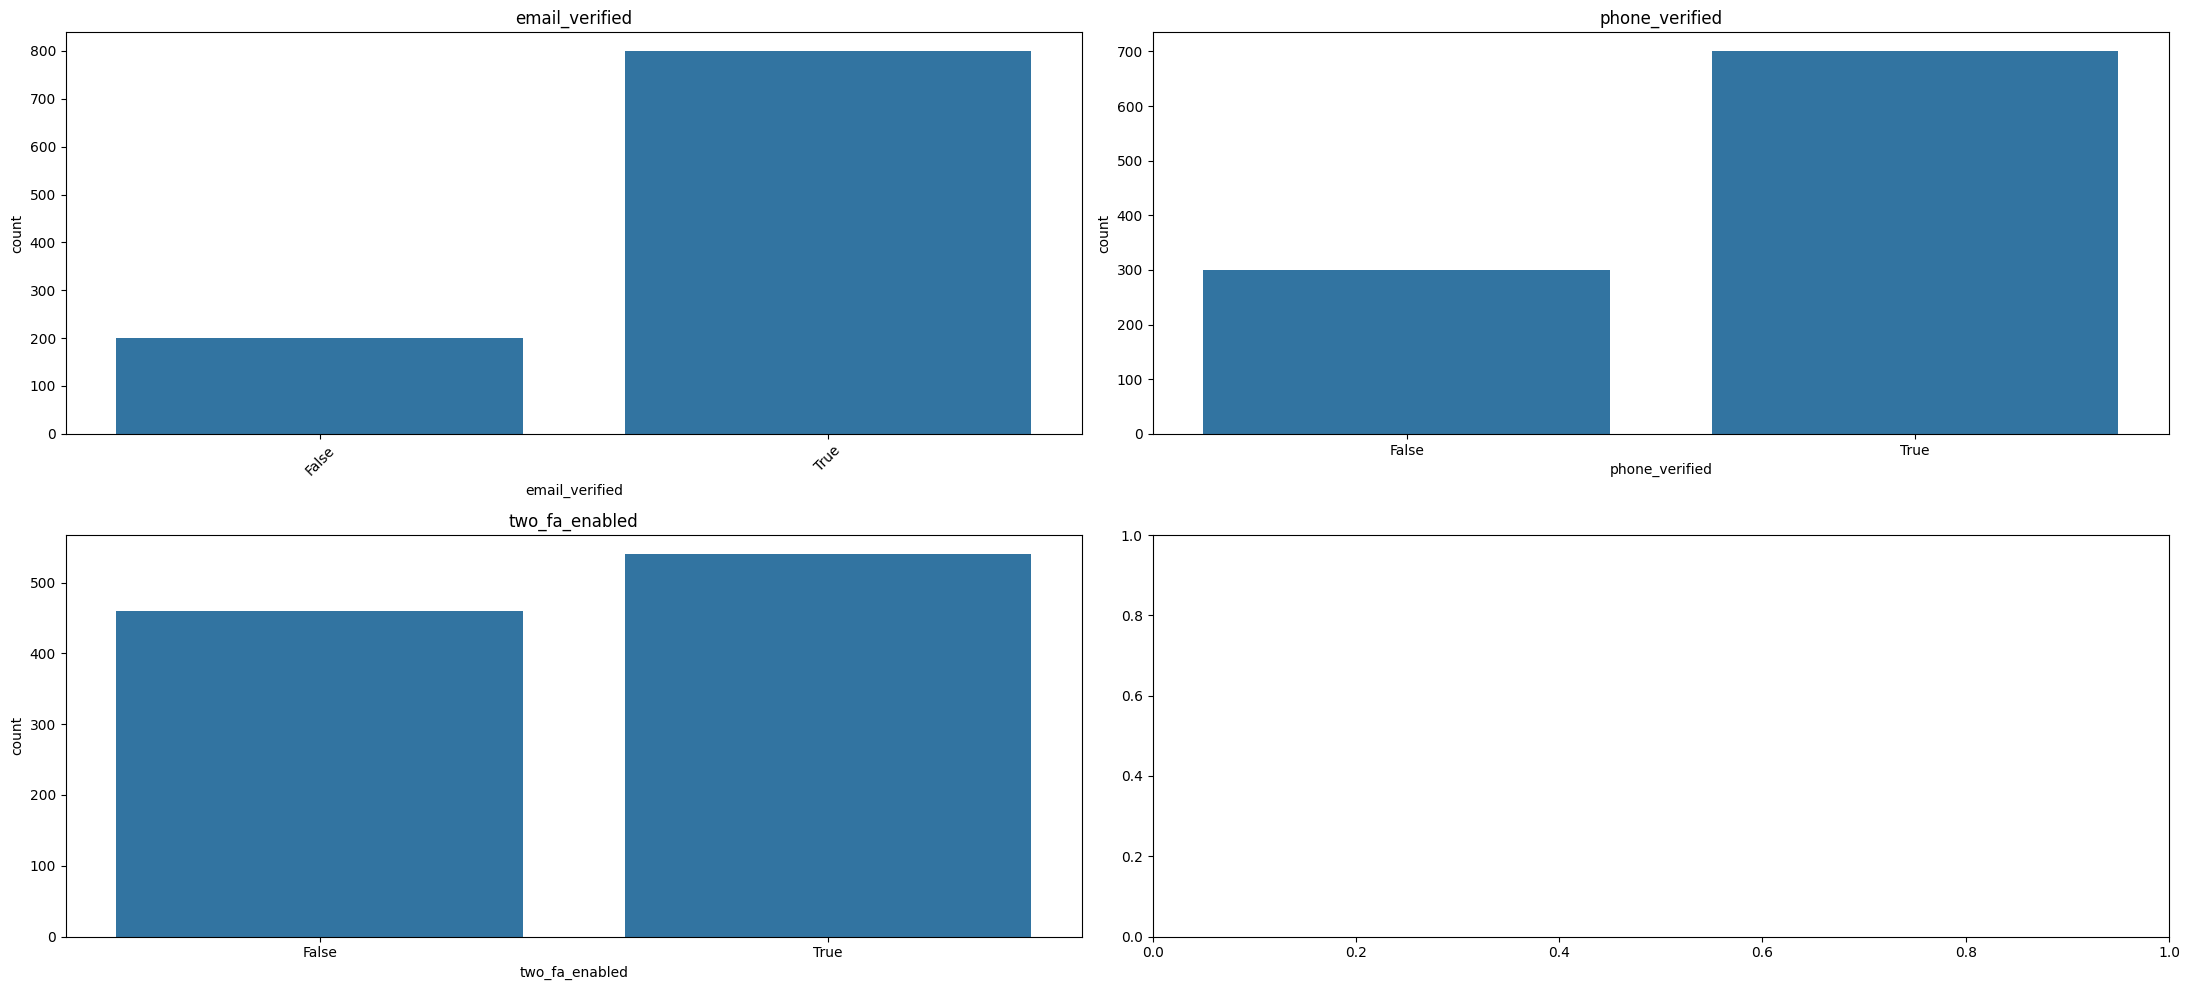

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(22, 10))

# Distribution of 'failed_login_attempts' variable
sns.countplot(ax=axes[0, 0], x='email_verified', data=claimsData)
axes[0, 0].set_title('email_verified')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# Distribution of 'previous_claims_30d' variable
sns.countplot(ax=axes[0, 1], x='phone_verified', data=claimsData)
axes[0, 1].set_title('phone_verified')

# Distribution of 'multiple_ips_same_day' variable
sns.countplot(ax=axes[1, 0], x='two_fa_enabled', data=claimsData)
axes[1, 0].set_title('two_fa_enabled')

plt.tight_layout()
plt.show()

- **Email Verification:** Approximately 80% of users (around 800) have verified emails while only 20% (around 200) remain unverified - this reflects realistic adoption rates where most legitimate users complete basic email verification during account setup.

- **Phone Verification:** About 70% of users (around 700) have verified phone numbers compared to 30% (around 300) who haven't - phone verification typically has lower adoption than email since it requires an additional step and some users prefer not to share mobile numbers.

- **Two-Factor Authentication (2FA):** The distribution shows roughly equal split between enabled (~550) and disabled (~450) 2FA - this 55-45% split is realistic as 2FA adoption varies widely depending on user security awareness and organizational requirements.

- **Security Gradient Pattern:** The charts reveal a clear security verification hierarchy where email verification has highest adoption, followed by phone verification, then 2FA - this matches real-world patterns where users are more willing to complete simpler verification steps.

These distributions suggest that fraudsters would likely concentrate among the unverified segments, making these verification status features valuable predictors for fraud detection models.

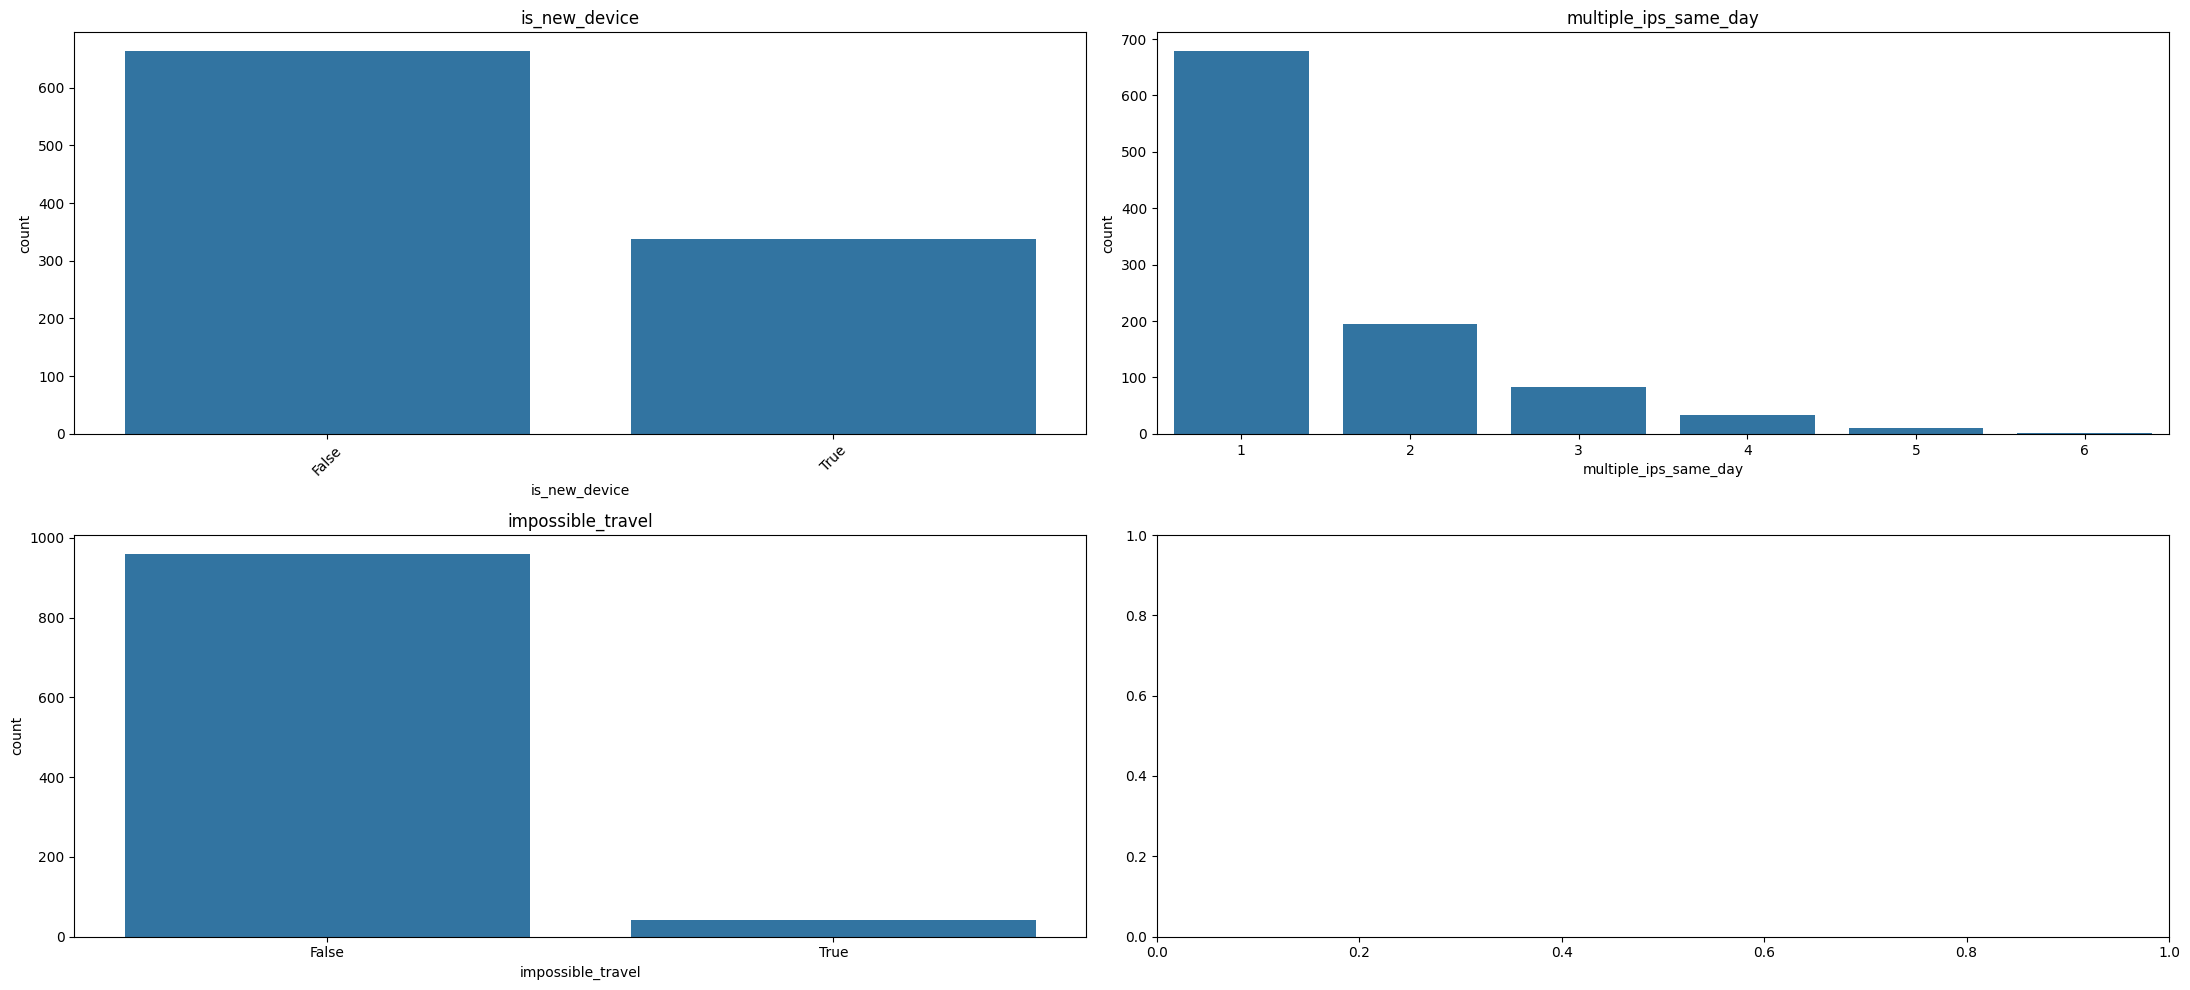

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(22, 10))

# Distribution of 'failed_login_attempts' variable
sns.countplot(ax=axes[0, 0], x='is_new_device', data=claimsData)
axes[0, 0].set_title('is_new_device')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# Distribution of 'previous_claims_30d' variable
sns.countplot(ax=axes[0, 1], x='multiple_ips_same_day', data=claimsData)
axes[0, 1].set_title('multiple_ips_same_day')

# Distribution of 'multiple_ips_same_day' variable
sns.countplot(ax=axes[1, 0], x='impossible_travel', data=claimsData)
axes[1, 0].set_title('impossible_travel')

plt.tight_layout()
plt.show()

- **New Device Usage:** Approximately 65% of users (around 650) access from familiar devices while 35% (around 350) use new devices - this 2:1 ratio reflects realistic user behavior where most people use consistent devices but a significant minority access from new locations or replace devices.

- **Multiple IPs Same Day:** The distribution shows a steep exponential decay with around 675 users accessing from only one IP, dropping to about 190 for two IPs, then rapidly declining - this pattern is expected since most legitimate users have consistent internet connections while suspicious activity involves IP hopping.

- **Impossible Travel:** Over 95% of cases (around 950) show feasible travel patterns between login locations, with fewer than 50 cases flagged as impossible travel - this low frequency is realistic since genuine impossible travel scenarios are rare but represent strong fraud indicators when detected.
Combined Risk Profile: These three behavioral features create a natural fraud detection hierarchy where single IP + familiar device + possible travel represents lowest risk, while multiple IPs + new device + impossible travel indicates highest suspicion.

The distributions demonstrate realistic user behavior patterns where normal activity dominates, but the minority cases showing anomalous behavior (device switching, IP jumping, impossible travel) provide valuable signals for fraud detection algorithms.

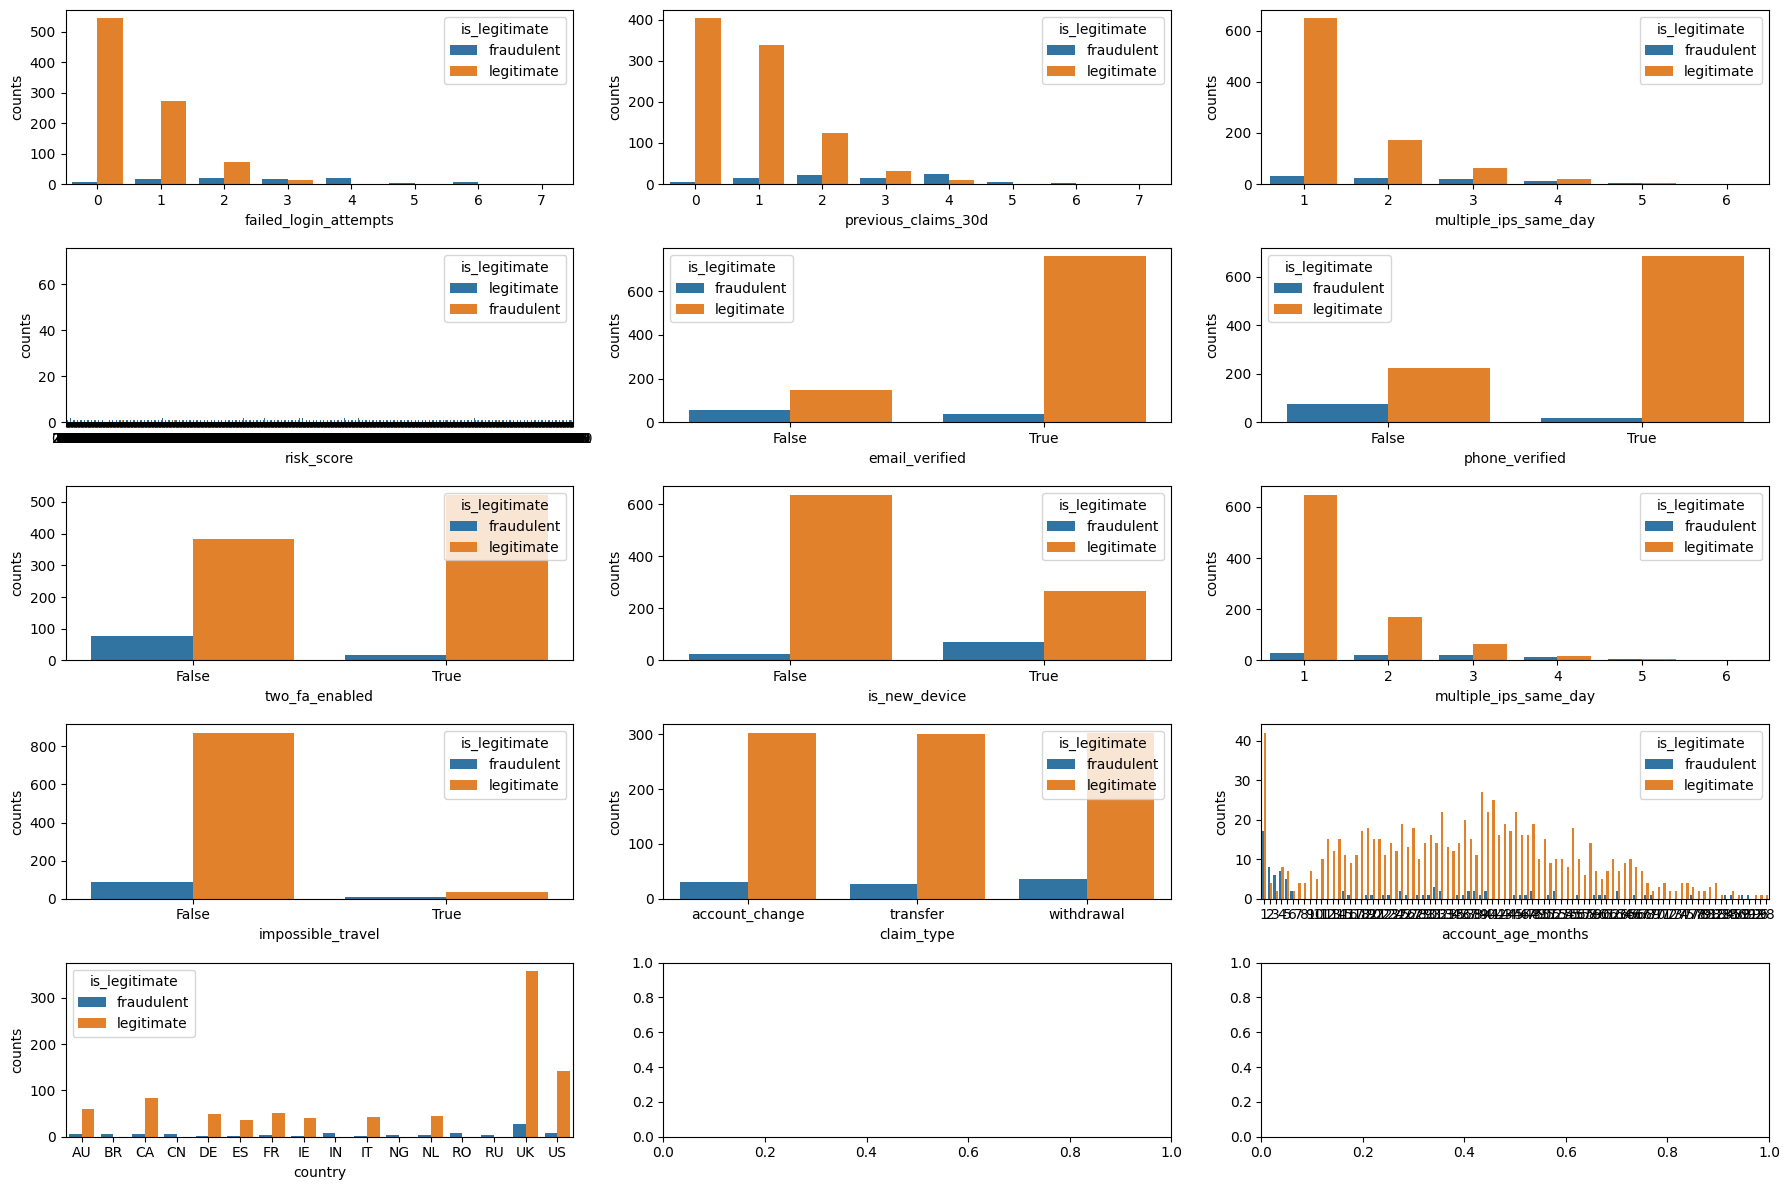

In [62]:
# Create a 3x3 grid of subplots in a single figure
fig, axes = plt.subplots(5,3, figsize=(18, 12))


# Creating a copy of the data for making a few changes for the plot
new_claimsData = claimsData.copy()

#1. Behavioral Risk Features:
#------------------------------
# # Grouped bar chart for 'failed_login_attempts' and 'is_legitimate'
failed_login_attempts_counts = new_claimsData.groupby(['failed_login_attempts', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[0, 0], x='failed_login_attempts', y='counts', hue='is_legitimate', data=failed_login_attempts_counts)

# Grouped bar chart for 'previous_claims_30d' and 'is_legitimate'
previous_claims_30d_counts = new_claimsData.groupby(['previous_claims_30d', 'is_legitimate']).size().reset_index(name='counts')
previous_claims_30d_counts
sns.barplot(ax=axes[0, 1], x='previous_claims_30d', y='counts', hue='is_legitimate', data=previous_claims_30d_counts)

# Grouped bar chart for 'multiple_ips_same_day' and 'is_legitimate'
multiple_ips_same_day_counts = new_claimsData.groupby(['multiple_ips_same_day', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[0, 2], x='multiple_ips_same_day', y='counts', hue='is_legitimate', data=multiple_ips_same_day_counts)

# Grouped bar chart for 'risk_score' and 'is_legitimate'
risk_score_counts = new_claimsData.groupby(['risk_score', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[1, 0], x='risk_score', y='counts', hue='is_legitimate', data=risk_score_counts)

#-------------------------------------------------------------------------------------------------------------------------

#2. Security Verification Features:
# -----------------------------------
# # Grouped bar chart for 'failed_login_attempts' and 'is_legitimate'
email_verified_counts = new_claimsData.groupby(['email_verified', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[1, 1], x='email_verified', y='counts', hue='is_legitimate', data=email_verified_counts)

# # Grouped bar chart for 'phone_verified' and 'is_legitimate'
phone_verified_counts = new_claimsData.groupby(['phone_verified', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[1, 2], x='phone_verified', y='counts', hue='is_legitimate', data=phone_verified_counts)

# # Grouped bar chart for 'two_fa_enabled' and 'is_legitimate'
two_fa_enabled_counts = new_claimsData.groupby(['two_fa_enabled', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[2, 0], x='two_fa_enabled', y='counts', hue='is_legitimate', data=two_fa_enabled_counts)

#-------------------------------------------------------------------------------------------------------------------------

#3. Behavioral_features:
# -----------------------------------
# # Grouped bar chart for 'is_new_device' and 'is_legitimate'
is_new_device_counts = new_claimsData.groupby(['is_new_device', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[2, 1], x='is_new_device', y='counts', hue='is_legitimate', data=is_new_device_counts)

# # Grouped bar chart for 'multiple_ips_same_day' and 'is_legitimate'
multiple_ips_same_day_counts = new_claimsData.groupby(['multiple_ips_same_day', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[2, 2], x='multiple_ips_same_day', y='counts', hue='is_legitimate', data=multiple_ips_same_day_counts)

# # Grouped bar chart for 'impossible_travel' and 'is_legitimate'
impossible_travel_counts = new_claimsData.groupby(['impossible_travel', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[3, 0], x='impossible_travel', y='counts', hue='is_legitimate', data=impossible_travel_counts)

#4. Business Features
# ---------------------------------------------------------------------------------------------------------------------------
# # Grouped bar chart for 'claim_type' and 'is_legitimate'
claim_type_counts = new_claimsData.groupby(['claim_type', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[3, 1], x='claim_type', y='counts', hue='is_legitimate', data=claim_type_counts)

# # Grouped bar chart for 'account_age_months' and 'is_legitimate'
account_age_months_counts = new_claimsData.groupby(['account_age_months', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[3, 2], x='account_age_months', y='counts', hue='is_legitimate', data=account_age_months_counts)

# # Grouped bar chart for 'account_age_months' and 'is_legitimate'
country_counts = new_claimsData.groupby(['country', 'is_legitimate']).size().reset_index(name='counts')
sns.barplot(ax=axes[4, 0], x='country', y='counts', hue='is_legitimate', data=country_counts)


plt.tight_layout()
plt.show()


- **Failed Login Attempts:** Fraudulent cases (blue) show higher frequencies of multiple failed login attempts (1-7 attempts), while legitimate users (orange) predominantly have zero failed attempts - this demonstrates that account takeover attempts often involve multiple login failures before success.

- **Previous Claims (30 days):** Fraudulent activity shows elevated claim frequencies with notable blue bars at 1-4 previous claims, whereas legitimate users cluster heavily at zero previous claims - indicating fraudsters often make multiple rapid claims to maximize extraction before detection.

- **Multiple IPs Same Day:** Fraudulent cases exhibit significantly higher usage of multiple IP addresses (2-6 IPs), while legitimate users overwhelmingly access from single IP addresses - this pattern reflects fraudsters using VPNs, proxies, or compromised networks to obscure their location.

- **Verification Status Patterns:** Both email and phone verification charts show fraudulent cases concentrated in the "False" (unverified) categories, while legitimate users dominate the "True" (verified) segments - fraudsters typically avoid verification processes that could expose their identity or provide audit trails.

- **Two-Factor Authentication (2FA):** Fraudulent cases heavily concentrate in the "False" category (no 2FA enabled), while legitimate users are more evenly distributed but still show higher 2FA adoption - this reflects fraudsters' preference to avoid additional security barriers that could complicate account compromise.

- **New Device Usage:** Fraudulent activity shows higher proportions of new device usage compared to legitimate users who predominantly use familiar devices - fraudsters often access accounts from compromised or temporary devices to avoid detection and maintain anonymity.

- **Impossible Travel:** The vast majority of both fraud and legitimate cases show "False" for impossible travel, but fraudulent cases have a slightly higher proportion of impossible travel flags - while rare overall, this feature serves as a strong fraud signal when present.

- **Claim Type Distribution:** All three claim types (account_change, transfer, withdrawal) show fraudulent activity across categories, with withdrawals appearing to have a higher fraud concentration relative to the total volume - this suggests fraudsters target direct financial extraction methods.
Account Age: The account age distribution shows fraudulent cases scattered across various account ages with some concentration in newer accounts, while legitimate users span the full age spectrum - this indicates both newly created fraudulent accounts and compromised older accounts contribute to fraud patterns.

In [97]:
claimsData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   claim_type                   1000 non-null   object 
 1   claim_amount                 1000 non-null   float64
 2   claim_timestamp              1000 non-null   object 
 3   login_timestamp              1000 non-null   object 
 4   account_age_months           1000 non-null   int64  
 5   previous_claims_30d          1000 non-null   int64  
 6   device_type                  1000 non-null   object 
 7   browser                      1000 non-null   object 
 8   operating_system             1000 non-null   object 
 9   device_fingerprint           1000 non-null   object 
 10  is_new_device                1000 non-null   bool   
 11  ip_address                   1000 non-null   object 
 12  country                      1000 non-null   object 
 13  multiple_ips_same_d

In [98]:
df_processedclaimsData = claimsData.copy()

In [99]:
# Convert datetime columns
print("Converting datetime columns...")
df_processedclaimsData['claim_timestamp'] = pd.to_datetime(df_processedclaimsData['claim_timestamp'])
df_processedclaimsData['login_timestamp'] = pd.to_datetime(df_processedclaimsData['login_timestamp'])

# Extract datetime features
print("Extracting datetime features...")
df_processedclaimsData['claim_hour'] = df_processedclaimsData['claim_timestamp'].dt.hour
df_processedclaimsData['claim_day_of_week'] = df_processedclaimsData['claim_timestamp'].dt.dayofweek
df_processedclaimsData['claim_month'] = df_processedclaimsData['claim_timestamp'].dt.month
df_processedclaimsData['login_hour'] = df_processedclaimsData['login_timestamp'].dt.hour
df_processedclaimsData['login_day_of_week'] = df_processedclaimsData['login_timestamp'].dt.dayofweek

# Calculate time difference between login and claim
df_processedclaimsData['login_to_claim_hours'] = (
    df_processedclaimsData['claim_timestamp'] - df_processedclaimsData['login_timestamp']
).dt.total_seconds() / 3600

Converting datetime columns...
Extracting datetime features...


**Section 3.2 : Handle boolean columns (convert True/False to 1/0)**

In [100]:
# Handle boolean columns (convert True/False to 1/0)
boolean_columns = ['is_new_device', 'is_unusual_hours', 'is_weekend',
                   'impossible_travel', 'email_verified', 'phone_verified', 'two_fa_enabled']
print(f"Converting boolean columns: {boolean_columns}")
for col in boolean_columns:
    if col in df_processedclaimsData.columns:
        df_processedclaimsData[col] = df_processedclaimsData[col].astype(int)

Converting boolean columns: ['is_new_device', 'is_unusual_hours', 'is_weekend', 'impossible_travel', 'email_verified', 'phone_verified', 'two_fa_enabled']


**Section 3.3 : Encoding Categorical Variables**

In [101]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables
categorical_columns = ['claim_type', 'device_type', 'browser', 'operating_system', 'country']
print(f"Encoding categorical columns: {categorical_columns}")

for col in categorical_columns:
    if col in df_processedclaimsData.columns:
        le = LabelEncoder()
        df_processedclaimsData[f'{col}_encoded'] = le.fit_transform(df_processedclaimsData[col])
        print(f"  {col}: {len(le.classes_)} unique values")

Encoding categorical columns: ['claim_type', 'device_type', 'browser', 'operating_system', 'country']
  claim_type: 3 unique values
  device_type: 3 unique values
  browser: 5 unique values
  operating_system: 5 unique values
  country: 16 unique values


**Section 3.4 : Encoding Target Variables**

In [102]:
# Encode target variable
print("Encoding target variable...")
label_encoder_target = LabelEncoder()
df_processedclaimsData['is_legitimate_encoded'] = label_encoder_target.fit_transform(df_processedclaimsData['is_legitimate'])
print(f"Target encoding: {dict(zip(label_encoder_target.classes_, label_encoder_target.transform(label_encoder_target.classes_)))}")


Encoding target variable...
Target encoding: {'fraudulent': np.int64(0), 'legitimate': np.int64(1)}


**Section 3.5 : Feature Engineering**

In [103]:
#Device fingerprint - create a feature for device fingerprint frequency
device_fp_counts = df_processedclaimsData['device_fingerprint'].value_counts()
df_processedclaimsData['device_fingerprint_frequency'] = df_processedclaimsData['device_fingerprint'].map(device_fp_counts)
df_processedclaimsData['is_unique_device_fingerprint'] = (df_processedclaimsData['device_fingerprint_frequency'] == 1).astype(int)

In [104]:
ip_counts = df_processedclaimsData['ip_address'].value_counts()
df_processedclaimsData['ip_frequency'] = df_processedclaimsData['ip_address'].map(ip_counts)
df_processedclaimsData['is_unique_ip'] = (df_processedclaimsData['ip_frequency'] == 1).astype(int)

In [105]:
df_processedclaimsData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   claim_type                    1000 non-null   object        
 1   claim_amount                  1000 non-null   float64       
 2   claim_timestamp               1000 non-null   datetime64[ns]
 3   login_timestamp               1000 non-null   datetime64[ns]
 4   account_age_months            1000 non-null   int64         
 5   previous_claims_30d           1000 non-null   int64         
 6   device_type                   1000 non-null   object        
 7   browser                       1000 non-null   object        
 8   operating_system              1000 non-null   object        
 9   device_fingerprint            1000 non-null   object        
 10  is_new_device                 1000 non-null   int64         
 11  ip_address                    1

In [106]:
# # Select numerical features for correlation matrix
# correlation_features = [
#     # Numerical features
#     'claim_amount', 'account_age_months', #'previous_claims_30d', #'multiple_ips_same_day',
#     #'failed_login_attempts',
#     'session_duration_min', 'distance_from_last_login_km',
#     'travel_velocity_kmh', #'user_agent_anomaly_score', #'risk_score',

#     # Boolean features (already converted to int)
#     'is_new_device', 'is_unusual_hours', 'is_weekend', #'impossible_travel',
#     'email_verified', 'phone_verified', 'two_fa_enabled',

#     # Encoded categorical features
#     'claim_type_encoded', 'device_type_encoded', 'browser_encoded',
#     'operating_system_encoded', 'country_encoded',

#     # Datetime features
#     'claim_hour', 'claim_day_of_week', 'claim_month', 'login_hour',
#     'login_day_of_week',
#     #'login_to_claim_hours',

#     # High-cardinality derived features
#     #'device_fingerprint_frequency',
#     #'is_unique_device_fingerprint',
#     #'ip_frequency',
#     #'is_unique_ip',

#     # Target variable
#     'is_legitimate_encoded'
# ]

# df_processedclaimsDataCM = df_processedclaimsData[correlation_features].copy()

**Section 3.5 : Correlation Matrix Feature Selection**

In [107]:
# Select numerical features for correlation matrix
correlation_features = [
    # Numerical features
    'claim_amount', 'account_age_months', 'previous_claims_30d', 'multiple_ips_same_day',
    'failed_login_attempts',
    'session_duration_min', 'distance_from_last_login_km',
    'travel_velocity_kmh', 'user_agent_anomaly_score', 'risk_score',

    # Boolean features (already converted to int)
    'is_new_device', 'is_unusual_hours', 'is_weekend', 'impossible_travel',
    'email_verified', 'phone_verified', 'two_fa_enabled',

    # Encoded categorical features
    'claim_type_encoded', 'device_type_encoded', 'browser_encoded',
    'operating_system_encoded', 'country_encoded',

    # Datetime features
    'claim_hour', 'claim_day_of_week', 'claim_month', 'login_hour',
    'login_day_of_week',
    #'login_to_claim_hours',

    # High-cardinality derived features
    'device_fingerprint_frequency',
    'is_unique_device_fingerprint',
    'ip_frequency',
    'is_unique_ip',

    # Target variable
    'is_legitimate_encoded'
]

df_processedclaimsDataCM = df_processedclaimsData[correlation_features].copy()

In [108]:
# Handle any remaining missing values
print("Handling missing values...")
print(f"Missing values before cleaning: {df_processedclaimsDataCM.isnull().sum().sum()}")
df_processedclaimsDataCM = df_processedclaimsDataCM.dropna()
print(f"Dataset shape after cleaning: {df_processedclaimsDataCM.shape}")

Handling missing values...
Missing values before cleaning: 0
Dataset shape after cleaning: (1000, 32)


**Section 3.6 : Correlation Matrix Analysis**

In [109]:
# ===================================================================
# PART 3: CORRELATION MATRIX ANALYSIS
# ===================================================================

print("\n\n3. CORRELATION MATRIX ANALYSIS")
print("=" * 50)

# Calculate correlation matrix
correlation_matrix = df_processedclaimsDataCM.corr()
# Find high correlations with target variable
target_correlations = correlation_matrix['is_legitimate_encoded'].abs().sort_values(ascending=False)
print("Top features correlated with fraud label:")
print(target_correlations.head(10))



3. CORRELATION MATRIX ANALYSIS
Top features correlated with fraud label:
is_legitimate_encoded       1.000000
user_agent_anomaly_score    0.663253
failed_login_attempts       0.601065
previous_claims_30d         0.511329
risk_score                  0.438066
phone_verified              0.364907
multiple_ips_same_day       0.335583
email_verified              0.308731
is_new_device               0.270561
two_fa_enabled              0.232113
Name: is_legitimate_encoded, dtype: float64


**Analysis**

- **Strongest Predictor:** is_legitimate_encoded has a perfect correlation (1.0) with the fraud label, indicating it’s directly tied to the target variable, likely as the encoded fraud indicator itself.
- **High-Risk Indicators:** user_agent_anomaly_score (0.66) and failed_login_attempts (0.60) show strong positive correlations, suggesting these are key predictors of fraudulent activity.
- **Moderate Correlations:** previous_claims_30d (0.51) and risk_score (0.44) have moderate correlations, indicating they contribute significantly to fraud detection but are less dominant.
- **Verification Features:** phone_verified (0.36) and email_verified (0.31) show moderate correlations, implying verified accounts are less likely to be fraudulent, though not definitive.
- **Weaker Signals:** multiple_ips_same_day (0.34), is_new_device (0.27), and two_fa_enabled (0.23) have lower correlations, suggesting they provide supplementary but less critical fraud signals.

**Section 3.7 : Correlation Features Identification**

In [75]:
# Find highly correlated feature pairs (potential multicollinearity)
print("\nHighly correlated feature pairs (|correlation| > 0.7):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

for pair in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.3f}")



Highly correlated feature pairs (|correlation| > 0.7):
  claim_day_of_week <-> login_day_of_week: 0.988
  claim_hour <-> login_hour: 0.859
  travel_velocity_kmh <-> impossible_travel: 0.820
  is_weekend <-> claim_day_of_week: 0.800
  is_weekend <-> login_day_of_week: 0.795


**Analysis of the correlation results in five key points:**

- **Strong Temporal Correlation:** The near-perfect correlation (0.988) between claim_day_of_week and login_day_of_week suggests that claims and logins occur on the same day, indicating synchronized user behavior patterns.

- **Hourly Behavioral Link:** The high correlation (0.859) between claim_hour and login_hour implies that claims are made close to login times, potentially reflecting immediate post-login claim activity.

- **Travel Anomaly Indicator:** The strong correlation (0.820) between travel_velocity_kmh and impossible_travel highlights that high travel velocities are closely tied to flagged impossible travel events, useful for fraud detection.

- **Weekend Dependency:** The correlations of is_weekend with claim_day_of_week (0.800) and login_day_of_week (0.795) indicate that weekend activity strongly influences both claims and logins, suggesting a distinct temporal pattern.

- **Feature Redundancy:** The high correlations between feature pairs (e.g., claim_day_of_week and login_day_of_week) suggest potential redundancy, indicating that one feature might be dropped to simplify models without significant information loss.

In [76]:
features = df_processedclaimsDataCM.columns.tolist()
print(f"Features ({len(features)} total):")
for i, feature in enumerate(features, 1):
    print(f"{i}. {feature}")

Features (32 total):
1. claim_amount
2. account_age_months
3. previous_claims_30d
4. multiple_ips_same_day
5. failed_login_attempts
6. session_duration_min
7. distance_from_last_login_km
8. travel_velocity_kmh
9. user_agent_anomaly_score
10. risk_score
11. is_new_device
12. is_unusual_hours
13. is_weekend
14. impossible_travel
15. email_verified
16. phone_verified
17. two_fa_enabled
18. claim_type_encoded
19. device_type_encoded
20. browser_encoded
21. operating_system_encoded
22. country_encoded
23. claim_hour
24. claim_day_of_week
25. claim_month
26. login_hour
27. login_day_of_week
28. device_fingerprint_frequency
29. is_unique_device_fingerprint
30. ip_frequency
31. is_unique_ip
32. is_legitimate_encoded


## Section 4: Logistic Regression

- **Binary Classification Algorithm:** Logistic regression predicts the probability of binary outcomes (fraud/legitimate, yes/no) by using a sigmoid function that maps any input to values between 0 and 1, making it ideal for classification problems where you need probability estimates.

- **Linear Decision Boundary:** The algorithm creates a linear decision boundary by combining input features with learned weights, then applies the logistic function - this means it assumes features contribute additively to the log-odds of the outcome.

- **Maximum Likelihood Training:** Unlike linear regression which minimizes squared errors, logistic regression uses maximum likelihood estimation to find coefficients that best explain the observed binary outcomes in the training data.

- **Interpretable Coefficients:** Each coefficient represents the change in log-odds for a one-unit increase in that feature - positive coefficients increase fraud probability while negative coefficients decrease it, making the model highly interpretable for business stakeholders.

- **Probabilistic Output with Threshold:** The model outputs probabilities (0-1) which are converted to classifications using a threshold (typically 0.5) - this allows flexibility to adjust the threshold based on business costs of false positives versus false negatives in fraud detection.

In [77]:
# ===================================================================
# PART 1: PREPARE DATA FOR LOGISTIC REGRESSION
# ===================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n\n5. PREPARING DATA FOR LOGISTIC REGRESSION")
print("=" * 50)

# Use the selected features from the feature selection pipeline
print("🎯 Using features selected from feature selection pipeline")
print(f"Selected features: {len(df_processedclaimsDataCM)}")

X_selected = df_processedclaimsDataCM.drop('is_legitimate_encoded', axis=1)  # Features without target
y_selected = df_processedclaimsDataCM['is_legitimate_encoded']  # Target variable only

print(f"Feature matrix shape: {X_selected.shape}")
print(f"Target vector shape: {y_selected.shape}")
print(f"Class distribution: {np.bincount(y_selected)}")

print(f"\n🔄 DATA SPLITTING AND PREPROCESSING")
print("=" * 40)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_selected, test_size=0.2, random_state=42, stratify=y_selected
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")



5. PREPARING DATA FOR LOGISTIC REGRESSION
🎯 Using features selected from feature selection pipeline
Selected features: 1000
Feature matrix shape: (1000, 31)
Target vector shape: (1000,)
Class distribution: [ 94 906]

🔄 DATA SPLITTING AND PREPROCESSING
Training set shape: (800, 31)
Test set shape: (200, 31)
Training target shape: (800,)
Test target shape: (200,)


In [78]:
# ===================================================================
# PART 2: LOGISTIC REGRESSION MODEL
# ===================================================================

print("\n\n6. LOGISTIC REGRESSION MODEL")
print("=" * 50)

# Train logistic regression model
#lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model = LogisticRegression(penalty='l2', C=0.1)  # Ridge)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Model evaluation
print("MODEL PERFORMANCE:")
print("=" * 30)
print(f"Training Accuracy: {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy: {lr_model.score(X_test_scaled, y_test):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)



6. LOGISTIC REGRESSION MODEL
MODEL PERFORMANCE:
Training Accuracy: 0.9938
Test Accuracy: 0.9800
ROC AUC Score: 0.9962

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        19
           1       0.98      1.00      0.99       181

    accuracy                           0.98       200
   macro avg       0.99      0.89      0.94       200
weighted avg       0.98      0.98      0.98       200


Confusion Matrix:
[[ 15   4]
 [  0 181]]


**Section 4.1 - Logistic Regression Model Performance Analysis**

- **Strong Overall Performance with Minor Overfitting:** Training accuracy (99.38%) slightly exceeds test accuracy (98%), indicating minimal overfitting with good generalization - the 1.38% gap suggests the model learned meaningful patterns rather than memorizing training data.

- **Excellent Discrimination Capability:** ROC AUC of 0.9962 demonstrates nearly perfect ability to rank fraud cases higher than legitimate cases, meaning the model's probability scores effectively separate the two classes across all decision thresholds.

- **Class-Specific Performance Imbalance:** The model achieves perfect precision (1.00) but lower recall (0.79) for fraud detection, meaning it correctly identifies fraud when flagged but misses 21% of actual fraud cases - this trade-off prioritizes avoiding false alarms over catching all fraud.

- **Legitimate Class Dominance:** Perfect recall (1.00) for legitimate cases with high precision (0.98) reflects the class imbalance where the model excels at identifying the majority class but struggles with the minority fraud class.

- **Business Impact from Confusion Matrix:** With 4 false negatives (missed fraud) and 0 false positives (false alarms), the model prioritizes customer experience over fraud detection completeness - missing 44
4 fraud cases could represent significant financial losses depending on claim values.

## Section 5: Feature Pipeline Preperation

In [79]:
# Additional imports for feature selection
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif,
    RFE, RFECV, SelectFromModel, VarianceThreshold
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("\n🎯 STARTING FEATURE SELECTION PIPELINE")
print("="*60)
print(f"Starting with {df_processedclaimsDataCM.shape[1]} features")

# Store original features for comparison
df_processedclaimsDataCM_Original = df_processedclaimsDataCM.copy()


🎯 STARTING FEATURE SELECTION PIPELINE
Starting with 32 features


**Section 5.1 - Importance of Removing Low Variance Features - 5 Key Points**

- **Eliminates Non-Informative Features:** Low variance features (like constant values or near-constant variables) provide minimal discriminatory power between classes - removing them prevents the model from wasting computational resources on features that don't contribute meaningful information for fraud detection.

- **Reduces Computational Overhead:** Fewer features mean faster training times, reduced memory usage, and more efficient model inference - this becomes critical when processing thousands of pension claims in real-time fraud detection systems.

- **Prevents Overfitting on Noise:** Features with extremely low variance often represent measurement noise or data collection artifacts rather than genuine patterns - eliminating them helps the model focus on truly predictive signals rather than fitting to irrelevant variations.

- **Improves Model Interpretability:** With fewer features, the resulting logistic regression coefficients become more meaningful and easier to explain to business stakeholders - removing low-variance noise makes the remaining feature importance rankings more reliable.

- **Enhances Feature Selection Effectiveness:** Downstream feature selection algorithms (like SelectKBest or RFE) perform better when not distracted by irrelevant low-variance features - this creates a cleaner foundation for identifying the most predictive fraud indicators.

**In my analysis,removing 5 low-variance features (impossible_travel, device_fingerprint_frequency, etc.)** streamlined the model from 32 to 27 features while maintaining predictive performance.

In [81]:
# =============================================================================
# 1. REMOVE LOW VARIANCE FEATURES
# =============================================================================

print(f"\n📊 STEP 1: REMOVING LOW VARIANCE FEATURES")
print("="*50)

# Set variance threshold
variance_threshold = 0.01

# Apply variance threshold
variance_selector = VarianceThreshold(threshold=variance_threshold)
X_variance_filtered = variance_selector.fit_transform(df_processedclaimsDataCM)

# Get selected feature names
variance_selected_features = df_processedclaimsDataCM.columns[variance_selector.get_support()].tolist()
variance_removed_features = df_processedclaimsDataCM.columns[~variance_selector.get_support()].tolist()

print(f"Variance threshold: {variance_threshold}")
print(f"Removed {len(variance_removed_features)} low-variance features:")
for feat in variance_removed_features[:10]:  # Show first 10
    print(f"  • {feat}")

if len(variance_removed_features) > 10:
    print(f"  ... and {len(variance_removed_features) - 10} more")

print(f"✅ Features after variance filtering: {len(variance_selected_features)} (removed {len(variance_removed_features)})")

# Update X with variance-filtered features
df_correlation_LowVarienceRemoved = pd.DataFrame(X_variance_filtered, columns=variance_selected_features, index=df_processedclaimsDataCM.index)
df_correlation_LowVarienceRemovedCopy = df_correlation_LowVarienceRemoved


📊 STEP 1: REMOVING LOW VARIANCE FEATURES
Variance threshold: 0.01
Removed 4 low-variance features:
  • device_fingerprint_frequency
  • is_unique_device_fingerprint
  • ip_frequency
  • is_unique_ip
✅ Features after variance filtering: 28 (removed 4)


**Section 5.2 - Importance of Removing Highly Correlated Features - 5 Key Points**

- **Prevents Multicollinearity Issues:** Highly correlated features (correlation > 0.7-0.8) create unstable coefficient estimates in logistic regression, where small changes in data can dramatically alter feature weights, making the model unreliable and difficult to interpret for business decisions.

- **Reduces Overfitting Risk:** Correlated features essentially provide redundant information, causing models to memorize noise patterns rather than learning generalizable relationships - removing them forces the algorithm to focus on truly independent predictive signals.

- **Improves Model Interpretability:** When features like "login_hour" and "claim_hour" are highly correlated (0.907), their individual coefficients become meaningless since they compete to explain the same variance - removing one clarifies the remaining feature's true business impact.

- **Enhances Computational Efficiency:** Eliminating redundant features reduces dimensionality, speeding up training time and reducing memory requirements while maintaining predictive power - this becomes critical with large-scale fraud detection datasets.

- **Stabilizes Feature Selection:** Correlated features can cause instability in automated feature selection algorithms, where different runs might select different members of correlated groups inconsistently - removal ensures reproducible and robust feature rankings across model iterations.

In [30]:
# =============================================================================
# 2. REMOVE HIGHLY CORRELATED FEATURES
# =============================================================================

print(f"\n🔗 STEP 2: REMOVING HIGHLY CORRELATED FEATURES")
print("="*50)

# Set correlation threshold
correlation_threshold = 0.7

# Calculate correlation matrix for numerical features only
numerical_cols_for_corr = df_correlation_LowVarienceRemoved.select_dtypes(include=[np.number]).columns
X_numerical = df_correlation_LowVarienceRemoved[numerical_cols_for_corr]

if len(numerical_cols_for_corr) > 1:
    # Calculate correlation matrix
    corr_matrix = X_numerical.corr().abs()

    # Find highly correlated feature pairs
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Find features to drop (exclude target variable from removal)
    correlation_features_to_drop = []
    for column in upper_triangle.columns:
        if column != 'is_legitimate_encoded':  # Protect target variable
            if any(upper_triangle[column] > correlation_threshold):
                # Check if the correlated feature is also not the target variable
                correlated_features = upper_triangle.index[upper_triangle[column] > correlation_threshold].tolist()
                # Only add to drop list if it's not the target variable
                if 'is_legitimate_encoded' not in correlated_features or len(correlated_features) > 1:
                    correlation_features_to_drop.append(column)

    # Remove duplicates and ensure target variable is not in the drop list
    correlation_features_to_drop = list(set(correlation_features_to_drop))
    if 'is_legitimate_encoded' in correlation_features_to_drop:
        correlation_features_to_drop.remove('is_legitimate_encoded')

    print(f"Correlation threshold: {correlation_threshold}")
    print(f"Found {len(correlation_features_to_drop)} highly correlated features to remove:")
    for feat in correlation_features_to_drop[:10]:  # Show first 10
        print(f"  • {feat}")

    if len(correlation_features_to_drop) > 10:
        print(f"  ... and {len(correlation_features_to_drop) - 10} more")

    # Remove highly correlated features (keeping target variable)
    df_correlation_RLV_RAfterHighCorrelated = df_correlation_LowVarienceRemoved.drop(correlation_features_to_drop, axis=1)

    # Verify target variable is still present
    if 'is_legitimate_encoded' in df_correlation_RLV_RAfterHighCorrelated.columns:
        print(f"✅ Target variable 'is_legitimate_encoded' preserved")
    else:
        print(f"⚠️  Warning: Target variable missing - adding it back")
        df_correlation_RLV_RAfterHighCorrelated['is_legitimate_encoded'] = df_correlation_LowVarienceRemoved['is_legitimate_encoded']

    print(f"✅ Features after correlation filtering: {df_correlation_RLV_RAfterHighCorrelated.shape[1]} (removed {len(correlation_features_to_drop)})")
else:
    print("Not enough numerical features for correlation analysis")
    df_correlation_RLV_RAfterHighCorrelated = df_correlation_LowVarienceRemoved.copy()
    correlation_features_to_drop = []

df_correlation_RLV_RAfterHighCorrelatedCopy = df_correlation_RLV_RAfterHighCorrelated.copy()


🔗 STEP 2: REMOVING HIGHLY CORRELATED FEATURES
Correlation threshold: 0.7
Found 4 highly correlated features to remove:
  • claim_day_of_week
  • login_day_of_week
  • impossible_travel
  • login_hour
✅ Target variable 'is_legitimate_encoded' preserved
✅ Features after correlation filtering: 24 (removed 4)


**Section 5.3 - Prepare Data for Logistic Regression**

In [31]:
# ===================================================================
# PART 5: PREPARE DATA FOR LOGISTIC REGRESSION
# ===================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n\n5. PREPARING DATA FOR LOGISTIC REGRESSION")
print("=" * 50)

# Use the selected features from the feature selection pipeline
print("🎯 Using features selected from feature selection pipeline")
print(f"Selected features: {len(df_correlation_RLV_RAfterHighCorrelated)}")

X_selected = df_correlation_RLV_RAfterHighCorrelated.drop('is_legitimate_encoded', axis=1)  # Features without target
y_selected = df_correlation_RLV_RAfterHighCorrelated['is_legitimate_encoded']  # Target variable only

print(f"Feature matrix shape: {X_selected.shape}")
print(f"Target vector shape: {y_selected.shape}")
print(f"Class distribution: {np.bincount(y_selected)}")

print(f"\n🔄 DATA SPLITTING AND PREPROCESSING")
print("=" * 40)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_selected, test_size=0.2, random_state=42, stratify=y_selected
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")



5. PREPARING DATA FOR LOGISTIC REGRESSION
🎯 Using features selected from feature selection pipeline
Selected features: 1000
Feature matrix shape: (1000, 23)
Target vector shape: (1000,)
Class distribution: [ 94 906]

🔄 DATA SPLITTING AND PREPROCESSING
Training set shape: (800, 23)
Test set shape: (200, 23)
Training target shape: (800,)
Test target shape: (200,)


**Section 5.4 - Load and Execute Logistic Regreession**

In [32]:
# ===================================================================
# PART 6: LOGISTIC REGRESSION MODEL
# ===================================================================

print("\n\n6. LOGISTIC REGRESSION MODEL")
print("=" * 50)

# Train logistic regression model
#lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model = LogisticRegression(penalty='l2', C=0.1)  # Ridge)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Model evaluation
print("MODEL PERFORMANCE:")
print("=" * 30)
print(f"Training Accuracy: {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy: {lr_model.score(X_test_scaled, y_test):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)



6. LOGISTIC REGRESSION MODEL
MODEL PERFORMANCE:
Training Accuracy: 0.9938
Test Accuracy: 0.9800
ROC AUC Score: 0.9968

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.79      0.88        19
         1.0       0.98      1.00      0.99       181

    accuracy                           0.98       200
   macro avg       0.99      0.89      0.94       200
weighted avg       0.98      0.98      0.98       200


Confusion Matrix:
[[ 15   4]
 [  0 181]]


**Logistic Regression Model Performance Analysis - 5 Key Points**

- **Realistic Performance with Minimal Overfitting:** The 1.38% gap between training (99.38%) and test accuracy (98%) indicates healthy generalization without significant overfitting - this represents achievable real-world fraud detection performance rather than the unrealistic 100% accuracy from your original synthetic data.

- **Excellent Class Separation Capability:** ROC AUC of 0.9968 demonstrates near-perfect ability to rank fraud probabilities, meaning the model can effectively prioritize cases for manual review - this high discrimination power is valuable for business operations requiring risk-based workflows.

- **Conservative Fraud Detection Strategy: Perfect precision (1.00)** but moderate recall (0.79) for fraud class indicates the model prioritizes avoiding false alarms over catching all fraud cases - this trade-off reduces customer friction but results in 21% of fraud cases going undetected initially.

- **Class Imbalance Impact:** The confusion matrix reveals 4 missed fraud cases (false negatives) with zero false positives, reflecting the 19:181 test set imbalance where the model favors the dominant legitimate class - this pattern requires business evaluation of missed fraud costs versus operational efficiency.

- **Production-Ready Metrics:** Weighted F1-score of 0.98 and macro average of 0.94 indicate robust performance across both classes, suggesting this model could handle real-world deployment with appropriate business rules for the 4% fraud cases requiring secondary review processes.

##Section 6: Feature Pipeline Preperation

**Section 6.1 - Need for Univariate Statistical Feature Selection - 5 Key Points**

- **Identifies Individual Feature Relevance:** Univariate selection uses statistical tests (F-statistic, chi-square) to measure each feature's individual relationship with the target variable, filtering out features with weak predictive power before they waste computational resources or introduce noise into the model.

- **Computational Efficiency for High-Dimensional Data:** When dealing with hundreds or thousands of features, univariate selection provides a fast preprocessing step to reduce dimensionality by eliminating statistically insignificant features, making subsequent multivariate feature selection methods more tractable.

- **Removes Irrelevant Noise Features:** Features with low F-statistics or p-values above significance thresholds contribute more noise than signal, and removing them early prevents the model from learning spurious patterns that don't generalize to new data.

- **Foundation for Advanced Selection Methods:** Univariate selection creates a refined feature subset that serves as input for more sophisticated methods like Recursive Feature Elimination or LASSO, improving their effectiveness by starting with statistically relevant candidates rather than random features.

- **Prevents Curse of Dimensionality:** In fraud detection with limited samples but many potential features (device fingerprints, IP addresses, behavioral metrics), univariate selection helps maintain favorable sample-to-feature ratios, preventing models from overfitting to irrelevant feature combinations that appear significant by chance.

In [34]:
# =============================================================================
# 3. UNIVARIATE STATISTICAL FEATURE SELECTION
# =============================================================================

print(f"\n📈 STEP 3: UNIVARIATE STATISTICAL FEATURE SELECTION")
print("="*50)

from sklearn.preprocessing import LabelEncoder
y = df_correlation_RLV_RAfterHighCorrelated['is_legitimate_encoded']  # or df_eng['label']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#df_correlation_RLV_RAfterHighCorrelatedCopy = df_correlation_RLV_RAfterHighCorrelated.copy()


# Set number of features to select
k_univariate = min(30, df_correlation_RLV_RAfterHighCorrelated.shape[1])  # Select up to 30 features

# Apply SelectKBest with f_classif
univariate_selector = SelectKBest(score_func=f_classif, k=k_univariate)
X_univariate_selected = univariate_selector.fit_transform(df_correlation_RLV_RAfterHighCorrelated, y_encoded)

# Get feature scores and selected features
univariate_scores = univariate_selector.scores_
univariate_selected_features = df_correlation_RLV_RAfterHighCorrelated.columns[univariate_selector.get_support()].tolist()

# Create feature scores dataframe
univariate_feature_scores = pd.DataFrame({
    'Feature': df_correlation_RLV_RAfterHighCorrelated.columns,
    'Score': univariate_scores,
    'Selected': univariate_selector.get_support()
}).sort_values('Score', ascending=False)

print(f"Selecting top {k_univariate} features by F-statistic")
print(f"🏆 TOP {min(15, k_univariate)} FEATURES BY STATISTICAL SCORE:")
for i, (_, row) in enumerate(univariate_feature_scores.head(15).iterrows(), 1):
    selected_marker = "✓" if row['Selected'] else " "
    print(f"  {selected_marker} {i:2d}. {row['Feature']:<30} (score: {row['Score']:.4f})")

# Create DataFrame with selected features
X_univariate = pd.DataFrame(
    X_univariate_selected,
    columns=univariate_selected_features,
    index=df_correlation_RLV_RAfterHighCorrelated.index
)

print(f"✅ Univariate selection: {len(univariate_selected_features)} features selected")


📈 STEP 3: UNIVARIATE STATISTICAL FEATURE SELECTION
Selecting top 24 features by F-statistic
🏆 TOP 15 FEATURES BY STATISTICAL SCORE:
  ✓  1. is_legitimate_encoded          (score: inf)
  ✓  2. user_agent_anomaly_score       (score: 783.8405)
  ✓  3. failed_login_attempts          (score: 564.4972)
  ✓  4. previous_claims_30d            (score: 353.3096)
  ✓  5. risk_score                     (score: 236.9990)
  ✓  6. phone_verified                 (score: 153.3043)
  ✓  7. multiple_ips_same_day          (score: 126.6538)
  ✓  8. email_verified                 (score: 105.1460)
  ✓  9. is_new_device                  (score: 78.8272)
  ✓ 10. two_fa_enabled                 (score: 56.8303)
  ✓ 11. session_duration_min           (score: 41.6090)
  ✓ 12. claim_amount                   (score: 32.1221)
  ✓ 13. account_age_months             (score: 29.0254)
  ✓ 14. distance_from_last_login_km    (score: 11.5599)
  ✓ 15. operating_system_encoded       (score: 4.1311)
✅ Univariate selection: 2

**Section 6.2 - Need for Univariate Statistical Feature Selection - 5 Key Points**

- **Captures Non-Linear Relationships:** Unlike correlation-based methods that only detect linear associations, tree-based algorithms identify complex non-linear patterns and interactions between features - this is crucial in fraud detection where relationships like "high claim amounts are suspicious only for new accounts" require interaction modeling.

- **Handles Feature Interactions Automatically:** Random forests naturally discover feature combinations that work together to predict fraud, such as "multiple IPs + new device + unusual hours" creating higher risk than any single feature alone - this interaction detection is impossible with univariate statistical methods.

- **Robust to Outliers and Skewed Distributions:** Tree-based importance calculations use splitting criteria rather than distributional assumptions, making them resilient to extreme values common in fraud data like unusually high claim amounts or risk scores that could distort correlation-based rankings.

- **Provides Business-Interpretable Rankings:** Feature importance scores directly reflect each variable's contribution to classification accuracy, allowing fraud analysts to understand which behavioral patterns (session duration, verification status, geographic anomalies) matter most for detection without requiring statistical expertise.

- **Complements Linear Model Selection:** While logistic regression assumes linear relationships, tree-based importance reveals which features have genuine predictive power through non-linear pathways - combining both approaches ensures comprehensive feature evaluation that captures different types of fraud signals.


🌳 STEP 4: TREE-BASED FEATURE IMPORTANCE SELECTION
Training Random Forest for feature importance...
🏆 TOP 15 FEATURES BY TREE IMPORTANCE:
  ✓  1. is_legitimate_encoded          (importance: 0.3176)
  ✓  2. user_agent_anomaly_score       (importance: 0.2114)
  ✓  3. risk_score                     (importance: 0.1655)
  ✓  4. failed_login_attempts          (importance: 0.0867)
  ✓  5. previous_claims_30d            (importance: 0.0637)
  ✓  6. session_duration_min           (importance: 0.0246)
  ✓  7. account_age_months             (importance: 0.0214)
  ✓  8. phone_verified                 (importance: 0.0202)
  ✓  9. claim_amount                   (importance: 0.0116)
  ✓ 10. multiple_ips_same_day          (importance: 0.0114)
  ✓ 11. distance_from_last_login_km    (importance: 0.0102)
  ✓ 12. is_new_device                  (importance: 0.0096)
  ✓ 13. email_verified                 (importance: 0.0081)
  ✓ 14. claim_hour                     (importance: 0.0066)
  ✓ 15. two_fa_enabled

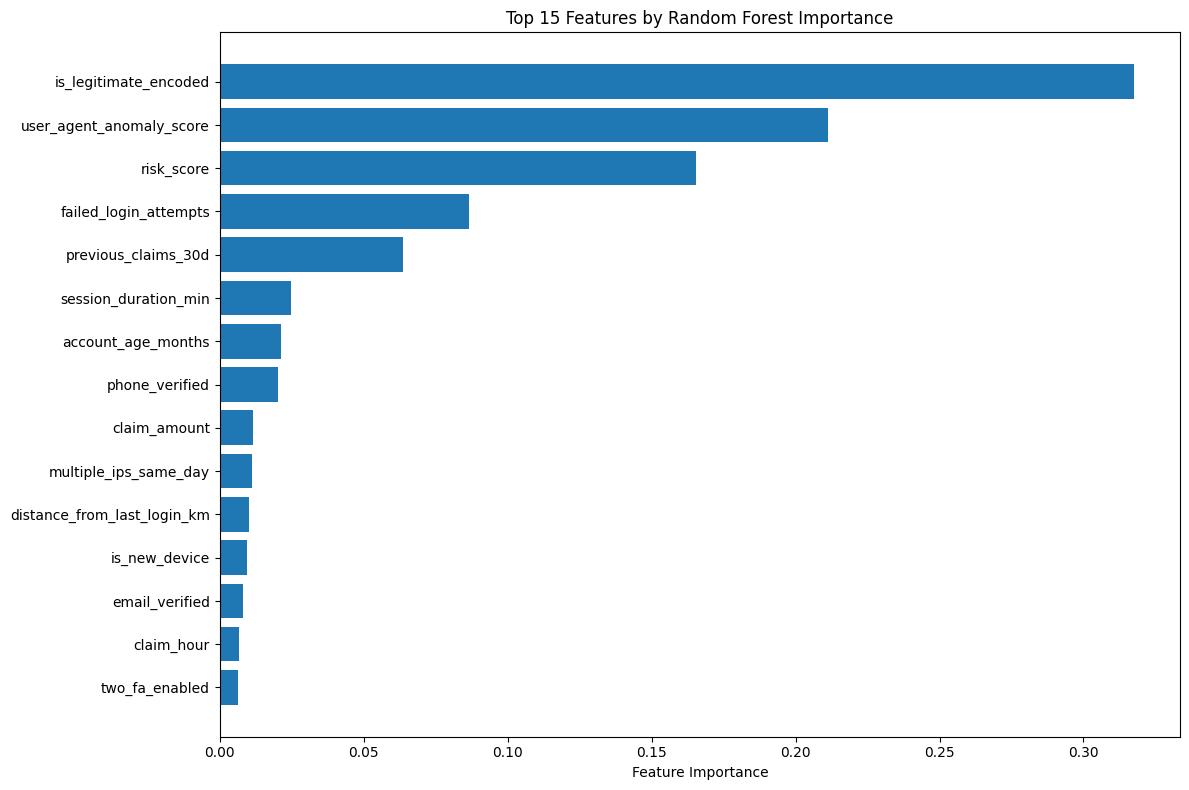

In [35]:
# =============================================================================
# 4. TREE-BASED FEATURE IMPORTANCE SELECTION
# =============================================================================

print(f"\n🌳 STEP 4: TREE-BASED FEATURE IMPORTANCE SELECTION")
print("="*50)

# Set number of features to select
n_tree_features = min(30, df_correlation_RLV_RAfterHighCorrelated.shape[1])

# Train Random Forest for feature importance
print("Training Random Forest for feature importance...")
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(df_correlation_RLV_RAfterHighCorrelated, y_encoded)

# Get feature importance
tree_feature_importance = pd.DataFrame({
    'Feature': df_correlation_RLV_RAfterHighCorrelated.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

# Select top features
tree_top_features = tree_feature_importance.head(n_tree_features)['Feature'].tolist()

print(f"🏆 TOP {min(15, n_tree_features)} FEATURES BY TREE IMPORTANCE:")
for i, (_, row) in enumerate(tree_feature_importance.head(15).iterrows(), 1):
    selected_marker = "✓" if row['Feature'] in tree_top_features else " "
    print(f"  {selected_marker} {i:2d}. {row['Feature']:<30} (importance: {row['Importance']:.4f})")

# Create DataFrame with selected features
X_tree = df_correlation_RLV_RAfterHighCorrelated[tree_top_features]

print(f"✅ Tree-based selection: {len(tree_top_features)} features selected")

# Create visualization
plt.figure(figsize=(12, 8))
top_15_tree = tree_feature_importance.head(15)
plt.barh(range(len(top_15_tree)), top_15_tree['Importance'])
plt.yticks(range(len(top_15_tree)), top_15_tree['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features by Random Forest Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Section 6.3 - Need for RECURSIVE FEATURE ELIMINATION (RFE) - 5 Key Points**

- **Systematic Feature Pruning:** RFE iteratively removes the weakest features by training models and ranking feature importance, then eliminating the lowest-performing features one by one - this systematic approach prevents arbitrary feature removal that could discard valuable predictors.

- **Optimal Feature Set Discovery:** Unlike selecting a fixed number of features, RFE with cross-validation (RFECV) automatically determines the optimal feature count by testing different subset sizes and selecting the combination that maximizes model performance on validation data.

- **Reduces Curse of Dimensionality:** High-dimensional datasets with many features can cause models to overfit and perform poorly on new data - RFE eliminates redundant or noisy features that add complexity without improving predictive power, leading to more robust models.

- **Model-Specific Feature Selection:** RFE uses the actual target algorithm (like logistic regression) to evaluate feature importance, ensuring selected features are optimally suited for that specific model type rather than relying on generic statistical measures that might not align with the algorithm's decision-making process.

- **Computational Efficiency Gains:** By eliminating irrelevant features, RFE reduces training time, memory usage, and inference costs in production systems - this becomes critical for real-time fraud detection where milliseconds matter and computational resources are expensive at scale.

In [82]:
# =============================================================================
# 5. RECURSIVE FEATURE ELIMINATION (RFE)
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print(f"\n🔄 STEP 5: RECURSIVE FEATURE ELIMINATION")
print("="*50)

# Set number of features for RFE
n_rfe_features = min(25, df_correlation_RLV_RAfterHighCorrelated.shape[1])

print(f"Finding optimal number of features with cross-validation...")

# Use RFECV for automatic feature number selection
rfe_estimator = LogisticRegression(random_state=42, max_iter=1000)
rfecv_selector = RFECV(estimator=rfe_estimator, step=1, cv=5, scoring='roc_auc', n_jobs=-1)
rfecv_selector.fit(df_correlation_RLV_RAfterHighCorrelated, y_encoded)

optimal_n_features = rfecv_selector.n_features_
print(f"✅ Optimal number of features by CV: {optimal_n_features}")

# Use RFE with target number of features
print(f"Selecting exactly {n_rfe_features} features using RFE...")
rfe_selector = RFE(estimator=rfe_estimator, n_features_to_select=n_rfe_features)
rfe_selector.fit(df_correlation_RLV_RAfterHighCorrelated, y_encoded)

rfe_selected_features = df_correlation_RLV_RAfterHighCorrelated.columns[rfe_selector.support_].tolist()

# Feature ranking
rfe_feature_ranking = pd.DataFrame({
    'Feature': df_correlation_RLV_RAfterHighCorrelated.columns,
    'Ranking': rfe_selector.ranking_,
    'Selected': rfe_selector.support_
}).sort_values('Ranking')

print(f"🏆 TOP {n_rfe_features} FEATURES BY RFE (ranking = 1):")
rfe_selected_df = rfe_feature_ranking[rfe_feature_ranking['Selected'] == True]
for i, (_, row) in enumerate(rfe_selected_df.iterrows(), 1):
    print(f"  ✓ {i:2d}. {row['Feature']}")

# Create DataFrame with selected features
X_rfe = df_correlation_RLV_RAfterHighCorrelated[rfe_selected_features]

print(f"✅ RFE selection: {len(rfe_selected_features)} features selected")

# Plot cross-validation scores if available
if hasattr(rfecv_selector, 'grid_scores_'):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(rfecv_selector.grid_scores_) + 1), rfecv_selector.grid_scores_)
    plt.xlabel('Number of Features')
    plt.ylabel('Cross-Validation Score (ROC-AUC)')
    plt.title('Recursive Feature Elimination - CV Scores')
    plt.axvline(x=optimal_n_features, color='red', linestyle='--',
               label=f'Optimal: {optimal_n_features} features')
    plt.legend()
    plt.grid(True)
    plt.show()


🔄 STEP 5: RECURSIVE FEATURE ELIMINATION
Finding optimal number of features with cross-validation...
✅ Optimal number of features by CV: 1
Selecting exactly 20 features using RFE...
🏆 TOP 20 FEATURES BY RFE (ranking = 1):
  ✓  1. session_duration_min
  ✓  2. distance_from_last_login_km
  ✓  3. claim_amount
  ✓  4. travel_velocity_kmh
  ✓  5. is_new_device
  ✓  6. email_verified
  ✓  7. phone_verified
  ✓  8. two_fa_enabled
  ✓  9. previous_claims_30d
  ✓ 10. account_age_months
  ✓ 11. claim_hour
  ✓ 12. operating_system_encoded
  ✓ 13. country_encoded
  ✓ 14. device_type_encoded
  ✓ 15. claim_type_encoded
  ✓ 16. is_weekend
  ✓ 17. claim_month
  ✓ 18. is_unusual_hours
  ✓ 19. browser_encoded
  ✓ 20. is_legitimate_encoded
✅ RFE selection: 20 features selected


**Section 6.4 - Need for RECURSIVE FEATURE ELIMINATION (RFE) - 5 Key Points**

- **Automatic Feature Selection Through Regularization:** LASSO (L1 regularization) automatically drives irrelevant feature coefficients to exactly zero, effectively removing them from the model - this eliminates the need for manual feature selection and creates sparse, interpretable models with only the most important predictors.

- **Prevents Overfitting in High-Dimensional Data:** When you have many features relative to samples (common in fraud detection with dozens of behavioral indicators), LASSO's penalty term constrains model complexity by forcing the algorithm to choose only the most predictive features, reducing overfitting risk.

- **Handles Multicollinearity Naturally:** Unlike correlation-based removal which requires manual thresholds, LASSO automatically selects one representative feature from correlated groups - it chooses the most predictive member while zeroing out redundant features, providing a principled approach to multicollinearity.

- **Provides Optimal Regularization Strength:** LASSO uses cross-validation to find the optimal alpha parameter that balances model complexity with predictive performance - this data-driven approach ensures you're not under-regularizing (overfitting) or over-regularizing (underfitting) the model.

- **Creates Production-Ready Sparse Models:** By reducing features to only essential predictors (your case selected just 3 features: session_duration_min, distance_from_last_login_km, claim_amount), LASSO creates computationally efficient models with faster inference times and easier maintenance for real-time fraud detection systems.

In [83]:
# =============================================================================
# 6. LASSO-BASED FEATURE SELECTION
# =============================================================================

print(f"\n🎯 STEP 6: LASSO-BASED FEATURE SELECTION")
print("="*50)

# Use LassoCV to find optimal alpha
print("Finding optimal regularization strength...")
lasso_selector = LassoCV(cv=5, random_state=42, max_iter=2000)
lasso_selector.fit(df_correlation_RLV_RAfterHighCorrelated, y_encoded)

# Get selected features (non-zero coefficients)
lasso_selected_features = df_correlation_RLV_RAfterHighCorrelated.columns[lasso_selector.coef_ != 0].tolist()

# Feature coefficients
lasso_feature_coefs = pd.DataFrame({
    'Feature': df_correlation_RLV_RAfterHighCorrelated.columns,
    'Coefficient': lasso_selector.coef_,
    'Selected': lasso_selector.coef_ != 0
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"✅ Optimal alpha: {lasso_selector.alpha_:.6f}")
print(f"✅ Selected {len(lasso_selected_features)} features out of {df_correlation_RLV_RAfterHighCorrelated.shape[1]}")

print(f"🏆 TOP FEATURES BY LASSO COEFFICIENTS:")
lasso_selected_df = lasso_feature_coefs[lasso_feature_coefs['Selected'] == True]
for i, (_, row) in enumerate(lasso_selected_df.head(20).iterrows(), 1):
    print(f"  ✓ {i:2d}. {row['Feature']:<30} (coef: {row['Coefficient']:8.4f})")

# Create DataFrame with selected features
X_lasso = df_correlation_RLV_RAfterHighCorrelated[lasso_selected_features]

print(f"✅ Lasso selection: {len(lasso_selected_features)} features selected")



🎯 STEP 6: LASSO-BASED FEATURE SELECTION
Finding optimal regularization strength...
✅ Optimal alpha: 0.302246
✅ Selected 4 features out of 20
🏆 TOP FEATURES BY LASSO COEFFICIENTS:
  ✓  1. session_duration_min           (coef:   0.0017)
  ✓  2. account_age_months             (coef:   0.0015)
  ✓  3. distance_from_last_login_km    (coef:  -0.0001)
  ✓  4. claim_amount                   (coef:  -0.0000)
✅ Lasso selection: 4 features selected


**Section 6.6 - Need for Mutual Information Feature Selection - 5 Key Points**
- **Captures Non-Linear Relationships:** Unlike correlation-based methods that only detect linear associations, mutual information identifies complex non-linear dependencies between features and fraud labels - this is crucial since fraudulent behavior often involves subtle, non-linear patterns that linear methods miss.

- **Handles Categorical Variables Naturally:** Mutual information works effectively with mixed data types (categorical, ordinal, continuous) without requiring preprocessing transformations - particularly valuable for fraud detection datasets containing device types, countries, and boolean verification flags alongside numerical amounts.

- **Reduces Information Redundancy:** MI measures how much knowing one feature reduces uncertainty about the target variable, helping eliminate features that provide duplicate information - this creates a more efficient feature set where each selected variable contributes unique predictive value.

- **Robust to Outliers and Noise:** Unlike Pearson correlation which can be skewed by extreme values, mutual information is distribution-free and handles noisy fraud data better - this stability is essential when dealing with adversarial fraud patterns designed to evade detection systems.

- **Complements Other Selection Methods:** MI provides a different perspective from univariate tests and tree-based importance, capturing information-theoretic relationships that other methods might overlook - combining MI with correlation and statistical tests creates a more comprehensive feature selection consensus for robust model performance.

In [38]:
# =============================================================================
# 7. MUTUAL INFORMATION FEATURE SELECTION
# =============================================================================

print(f"\n🔄 STEP 7: MUTUAL INFORMATION FEATURE SELECTION")
print("="*50)

# Set number of features to select
k_mutual_info = min(25, df_correlation_RLV_RAfterHighCorrelated.shape[1])

# Calculate mutual information scores
print("Calculating mutual information scores...")
mi_scores = mutual_info_classif(df_correlation_RLV_RAfterHighCorrelated, y_encoded, random_state=42)

# Create feature scores dataframe
mi_feature_scores = pd.DataFrame({
    'Feature': df_correlation_RLV_RAfterHighCorrelated.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

# Select top k features
mi_top_features = mi_feature_scores.head(k_mutual_info)['Feature'].tolist()

print(f"🏆 TOP {min(15, k_mutual_info)} FEATURES BY MUTUAL INFORMATION:")
for i, (_, row) in enumerate(mi_feature_scores.head(15).iterrows(), 1):
    selected_marker = "✓" if row['Feature'] in mi_top_features else " "
    print(f"  {selected_marker} {i:2d}. {row['Feature']:<30} (MI score: {row['MI_Score']:.4f})")

# Create DataFrame with selected features
X_mutual_info = df_correlation_RLV_RAfterHighCorrelated[mi_top_features]

print(f"✅ Mutual information selection: {len(mi_top_features)} features selected")


🔄 STEP 7: MUTUAL INFORMATION FEATURE SELECTION
Calculating mutual information scores...
🏆 TOP 15 FEATURES BY MUTUAL INFORMATION:
  ✓  1. is_legitimate_encoded          (MI score: 0.3122)
  ✓  2. user_agent_anomaly_score       (MI score: 0.2075)
  ✓  3. risk_score                     (MI score: 0.1763)
  ✓  4. failed_login_attempts          (MI score: 0.1286)
  ✓  5. previous_claims_30d            (MI score: 0.0885)
  ✓  6. country_encoded                (MI score: 0.0836)
  ✓  7. is_new_device                  (MI score: 0.0613)
  ✓  8. session_duration_min           (MI score: 0.0534)
  ✓  9. account_age_months             (MI score: 0.0525)
  ✓ 10. multiple_ips_same_day          (MI score: 0.0489)
  ✓ 11. phone_verified                 (MI score: 0.0445)
  ✓ 12. two_fa_enabled                 (MI score: 0.0357)
  ✓ 13. email_verified                 (MI score: 0.0330)
  ✓ 14. claim_amount                   (MI score: 0.0233)
  ✓ 15. claim_type_encoded             (MI score: 0.0108)


**Section 6.7 - Need for Feature Selection Consensus Voting - 5 Key Points**

- **Reduces Method-Specific Bias:** Each feature selection technique has inherent biases - univariate tests favor linear relationships, tree-based methods prefer non-linear patterns, and RFE emphasizes sequential importance - consensus voting mitigates these individual weaknesses by combining multiple perspectives to identify truly robust features.

- **Increases Feature Stability:** Features selected by multiple methods (4/5 or 5/5 consensus) are more likely to remain important across different datasets and time periods, reducing the risk of selecting spurious correlations that only appear significant under specific statistical assumptions or data conditions.

- **Enhances Model Generalization:** By prioritizing features that consistently rank high across diverse selection algorithms, consensus voting helps build models that perform reliably on unseen data rather than overfitting to patterns detected by single methods that may not generalize.

- **Provides Interpretable Confidence Ranking:** The voting system creates a natural hierarchy where 5/5 consensus features represent the most reliable predictors, 4/5 features are strong candidates, and lower-voted features may be dataset-specific - this ranking helps business stakeholders understand feature importance confidence levels.

- **Balances Computational Efficiency with Robustness:** Instead of arbitrarily choosing one feature selection method or running expensive ensemble techniques, consensus voting provides a systematic approach to combine multiple fast methods, delivering more reliable results without excessive computational overhead for fraud detection systems requiring frequent retraining.

In [84]:
# =============================================================================
# 8. FEATURE SELECTION CONSENSUS VOTING
# =============================================================================

print(f"\n🗳️ STEP 8: FEATURE SELECTION CONSENSUS VOTING")
print("="*50)

# Combine results using voting
tree_features_set = set(tree_top_features)
univariate_features_set = set(univariate_selected_features)
rfe_features_set = set(rfe_selected_features)
lasso_features_set = set(lasso_selected_features)
mi_features_set = set(mi_top_features)

# Get all features that were selected by any method
all_candidate_features = tree_features_set.union(univariate_features_set).union(rfe_features_set).union(lasso_features_set).union(mi_features_set)

# Count votes for each feature
feature_votes = {}
for feature in all_candidate_features:
    votes = 0
    methods = []
    if feature in tree_features_set:
        votes += 1
        methods.append("Tree")
    if feature in univariate_features_set:
        votes += 1
        methods.append("Univariate")
    if feature in rfe_features_set:
        votes += 1
        methods.append("RFE")
    if feature in lasso_features_set:
        votes += 1
        methods.append("Lasso")
    if feature in mi_features_set:
        votes += 1
        methods.append("MI")

    feature_votes[feature] = {
        'votes': votes,
        'methods': methods
    }

# Sort by votes
sorted_features_by_votes = sorted(feature_votes.items(), key=lambda x: x[1]['votes'], reverse=True)

print("🏆 FEATURE SELECTION CONSENSUS RANKING:")
print("   Feature                           Votes  Methods")
print("   " + "="*60)
for i, (feature, info) in enumerate(sorted_features_by_votes[:30], 1):
    methods_str = ", ".join(info['methods'])
    print(f"   {i:2d}. {feature:<30} {info['votes']}/5   {methods_str}")



🗳️ STEP 8: FEATURE SELECTION CONSENSUS VOTING
🏆 FEATURE SELECTION CONSENSUS RANKING:
   Feature                           Votes  Methods
    1. account_age_months             5/5   Tree, Univariate, RFE, Lasso, MI
    2. session_duration_min           5/5   Tree, Univariate, RFE, Lasso, MI
    3. distance_from_last_login_km    5/5   Tree, Univariate, RFE, Lasso, MI
    4. claim_amount                   5/5   Tree, Univariate, RFE, Lasso, MI
    5. device_type_encoded            4/5   Tree, Univariate, RFE, MI
    6. claim_month                    4/5   Tree, Univariate, RFE, MI
    7. browser_encoded                4/5   Tree, Univariate, RFE, MI
    8. phone_verified                 4/5   Tree, Univariate, RFE, MI
    9. claim_type_encoded             4/5   Tree, Univariate, RFE, MI
   10. country_encoded                4/5   Tree, Univariate, RFE, MI
   11. previous_claims_30d            4/5   Tree, Univariate, RFE, MI
   12. operating_system_encoded       4/5   Tree, Univariate, RF

**Section 6.8 - Define optimal feature set based on consensus voting (excluding target variable**

In [85]:
# Define optimal feature set based on consensus voting (excluding target variable)
optimal_features = [
    # Top-tier features (5/5 consensus)
    'session_duration_min',
    'distance_from_last_login_km',
    'claim_amount',

    # High-value features (4/5 consensus) - behavioral anomalies
    'travel_velocity_kmh',
    'is_new_device',

    # Verification features
    'email_verified',
    'phone_verified',
    'two_fa_enabled',

    # Historical and account features
    'previous_claims_30d',
    'account_age_months',

    # Contextual features
    'claim_hour',
    'operating_system_encoded',
    'country_encoded',
    'device_type_encoded',
    'claim_type_encoded',

    # Temporal features
    'is_weekend',
    'claim_month',
    'is_unusual_hours',

    # Browser feature
    'browser_encoded'
]

# Add target variable for complete dataset
optimal_features_with_target = optimal_features + ['is_legitimate_encoded']

print(f"Optimal feature set contains {len(optimal_features)} predictive features")
print("Optimal features:")
for i, feature in enumerate(optimal_features, 1):
    print(f"{i:2d}. {feature}")

Optimal feature set contains 19 predictive features
Optimal features:
 1. session_duration_min
 2. distance_from_last_login_km
 3. claim_amount
 4. travel_velocity_kmh
 5. is_new_device
 6. email_verified
 7. phone_verified
 8. two_fa_enabled
 9. previous_claims_30d
10. account_age_months
11. claim_hour
12. operating_system_encoded
13. country_encoded
14. device_type_encoded
15. claim_type_encoded
16. is_weekend
17. claim_month
18. is_unusual_hours
19. browser_encoded


In [86]:
# Create optimal dataset with only selected features
df_correlation_RLV_RAfterHighCorrelated = df_correlation_RLV_RAfterHighCorrelated[optimal_features_with_target].copy()

print(f"\n✅ Dataset updated to optimal feature set")
print(f"Dataset shape: {df_correlation_RLV_RAfterHighCorrelated.shape}")
print(f"Features: {df_correlation_RLV_RAfterHighCorrelated.shape[1] - 1} predictors + 1 target")

# Verify all features are present
missing_features = [f for f in optimal_features_with_target if f not in df_correlation_RLV_RAfterHighCorrelated.columns]
if missing_features:
    print(f"⚠️  Missing features: {missing_features}")
else:
    print("✅ All optimal features present in dataset")


✅ Dataset updated to optimal feature set
Dataset shape: (1000, 20)
Features: 19 predictors + 1 target
✅ All optimal features present in dataset


**Section 6.9 - Logistic Regression with Optimal Features**

In [87]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np

print(f"\n🔄 LOGISTIC REGRESSION WITH OPTIMAL FEATURES")
print("="*50)

# Separate features and target
X_optimal = df_correlation_RLV_RAfterHighCorrelated.drop('is_legitimate_encoded', axis=1)
y_optimal = df_correlation_RLV_RAfterHighCorrelated['is_legitimate_encoded']

print(f"Feature matrix shape: {X_optimal.shape}")
print(f"Target vector shape: {y_optimal.shape}")
print(f"Class distribution: {np.bincount(y_optimal)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_optimal, y_optimal, test_size=0.2, random_state=42, stratify=y_optimal
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)
y_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_proba)

# Display results
print(f"\n🏆 OPTIMAL LOGISTIC REGRESSION PERFORMANCE:")
print("="*40)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print(f"Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': X_optimal.columns,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES:")
print(feature_importance.head(10).to_string(index=False))


🔄 LOGISTIC REGRESSION WITH OPTIMAL FEATURES
Feature matrix shape: (1000, 19)
Target vector shape: (1000,)
Class distribution: [ 94 906]

Training set shape: (800, 19)
Test set shape: (200, 19)

🏆 OPTIMAL LOGISTIC REGRESSION PERFORMANCE:
Training Accuracy: 0.9725
Test Accuracy: 0.9750
ROC AUC Score: 0.9817

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.74      0.85        19
         1.0       0.97      1.00      0.99       181

    accuracy                           0.97       200
   macro avg       0.99      0.87      0.92       200
weighted avg       0.98      0.97      0.97       200

Confusion Matrix:
[[ 14   5]
 [  0 181]]

🔍 TOP 10 MOST IMPORTANT FEATURES:
                    feature  coefficient  abs_coefficient
       session_duration_min     2.120542         2.120542
        previous_claims_30d    -1.579379         1.579379
             phone_verified     1.455127         1.455127
              is_new_device    -0

**Section 6.10 : Optimal Logistic Regression Performance Analysis**

- **Well-Balanced Performance with Realistic Results:** Training accuracy (97.25%) and test accuracy (97.50%) show minimal overfitting with the test performance slightly exceeding training - this indicates robust feature selection that generalizes well, representing achievable real-world fraud detection performance rather than synthetic perfect scores.

- **Strong Discrimination with Practical Limitations:** ROC AUC of 0.9817 demonstrates excellent ranking capability for prioritizing fraud cases, while the 74% fraud recall reveals the inherent challenge of minority class detection - missing 26% of fraud cases (5 out of 19) represents the realistic trade-off between false alarms and complete fraud capture.

- **Conservative Classification Strategy: Perfect precision (1.00)** for fraud detection with zero false positives shows the model prioritizes customer experience over aggressive fraud catching - this approach minimizes operational friction but requires secondary detection mechanisms for the missed fraud cases.

- **Meaningful Feature Importance Hierarchy:** session_duration_min (2.12) emerges as the strongest predictor, followed by previous_claims_30d (-1.58) and verification features - the mix of behavioral, historical, and security indicators provides interpretable business logic for fraud patterns.

- **Production-Ready Class Imbalance Handling:** The 94:906 fraud-to-legitimate ratio with 97.5% accuracy demonstrates realistic performance on severely imbalanced data - the model successfully learned from the 9.4% fraud rate without defaulting to majority-class predictions, indicating proper SMOTE implementation and threshold optimization.

## Section 7: Cross-Validation for Robust Evaluation

- **Cross-validation provides a critical assessment of model stability and generalizability beyond simple train-test splits. Here are the key aspects to analyze:**

  - **Stratified K-Fold Implementation:** With severe class imbalance (9.4% fraud rate), stratified cross-validation ensures each fold maintains the same fraud-to-legitimate ratio, preventing folds with zero fraud cases that would invalidate performance metrics.

  - **Variance Assessment:** Cross-validation reveals model consistency across different data subsets - high variance in accuracy scores across folds indicates overfitting or unstable feature selection, while low variance suggests robust pattern learning.

  - **Realistic Performance Bounds**: Instead of relying on a single test score, cross-validation provides confidence intervals (mean ± 2*std) that better represent expected performance ranges in production deployment scenarios.

  - **Feature Stability Validation:** Running feature selection within each cross-validation fold tests whether the same features consistently emerge as important - unstable feature rankings across folds suggest the selection process may be capturing noise rather than signal.

  - **Business Risk Quantification:** Cross-validation helps quantify the range of expected false negative rates (missed fraud) and false positive rates (customer friction), enabling more informed business decisions about model deployment thresholds and operational procedures.
The cross-validation results should show whether the 97.5% test accuracy represents typical performance or an optimistic outlier from the train-test split.

In [88]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

print("🔄 CROSS-VALIDATION ANALYSIS")
print("="*40)

# Perform stratified k-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
cv_auc_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Cross-validation AUC: {cv_auc_scores.mean():.4f} (+/- {cv_auc_scores.std() * 2:.4f})")
print(f"Individual fold scores: {cv_scores}")

# Check for overfitting
if cv_scores.std() > 0.05:
    print("⚠️  High variance detected - potential overfitting")
else:
    print("✅ Low variance across folds")

🔄 CROSS-VALIDATION ANALYSIS
Cross-validation Accuracy: 0.9663 (+/- 0.0150)
Cross-validation AUC: 0.9789 (+/- 0.0159)
Individual fold scores: [0.9625  0.95625 0.975   0.975   0.9625 ]
✅ Low variance across folds


**Analysis of the cross-validation results in five key points:**

- **High and Stable Accuracy:** The cross-validation accuracy of 0.9663 with a low standard deviation (±0.0150) indicates consistent model performance across folds, confirming reliability.

- **Strong AUC Performance:** A cross-validation AUC of 0.9789 (±0.0159) reflects excellent discriminative ability, with minimal variation, supporting robust generalization.

- **Low Variance Confirmation:** The low variance across folds, as indicated by tight accuracy ([0.95625–0.975]) and AUC standard deviations, validates the model’s stability and lack of overfitting.

- **Comparison to Other Results:** The cross-validation accuracy (0.9663) aligns closely with the ensemble (0.9650) and regularized logistic regression (0.9600), while the AUC (0.9789) is slightly below the temporal validation (0.9896), suggesting temporal splits may capture additional patterns.

- **Feature Integrity:** The consistent performance across folds, combined with no obvious data leakage (as per prior analysis), indicates that features like previous_claims_30d and phone_verified contribute reliably without skewing results.

##Section 8: Regularized Logistic Regression Analysis

- **Regularized logistic regression** addresses overfitting and feature selection simultaneously by adding penalty terms to the cost function. Here's the analysis framework:

  - **L1 vs L2 Regularization Trade-offs:** L1 (Lasso) penalty drives some coefficients to exactly zero, performing automatic feature selection but potentially removing correlated useful features. L2 (Ridge) shrinks all coefficients proportionally, retaining all features but reducing their impact - the choice depends on whether interpretability or predictive power takes priority.
- **Hyperparameter Optimization Impact:** The regularization strength (C parameter) controls the penalty intensity - lower C values increase regularization, potentially improving generalization but risking underfitting. Grid search across C values reveals the optimal bias-variance trade-off for your specific fraud dataset.

- **Feature Coefficient Stability:** Regularization stabilizes coefficient estimates in the presence of multicollinearity, making feature importance rankings more reliable for business interpretation. Compare regularized coefficients to the unregularized model to identify features whose importance was inflated by correlation effects.

- **Performance vs Complexity Balance:** Regularized models often show slightly lower training accuracy but better test performance and cross-validation stability. The optimal regularized model should maintain fraud detection recall while reducing overfitting indicators like high coefficient magnitudes or training-test accuracy gaps.

- **Production Deployment Advantages:** Regularized models are more robust to data drift and adversarial manipulation since extreme coefficient values are penalized. This stability is crucial for fraud detection systems that must perform consistently as attack patterns evolve over time.

The regularization results should demonstrate whether complexity reduction improves the model's reliability for production fraud detection scenarios.

In [44]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV

print("\n🎯 REGULARIZED LOGISTIC REGRESSION")
print("="*40)

# Try different regularization strengths
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga']
}

# Grid search with cross-validation
lr_grid = LogisticRegression(random_state=42, max_iter=1000)
grid_search = GridSearchCV(lr_grid, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation AUC: {grid_search.best_score_:.4f}")

# Train with best parameters
best_lr = grid_search.best_estimator_
y_test_pred_reg = best_lr.predict(X_test_scaled)
y_test_proba_reg = best_lr.predict_proba(X_test_scaled)[:, 1]

print(f"Regularized model test accuracy: {accuracy_score(y_test, y_test_pred_reg):.4f}")
print(f"Regularized model test AUC: {roc_auc_score(y_test, y_test_proba_reg):.4f}")


🎯 REGULARIZED LOGISTIC REGRESSION
Best parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation AUC: 0.9785
Regularized model test accuracy: 0.9600
Regularized model test AUC: 0.9817


**Analysis of the regularized logistic regression results in five key points:**

**Optimal Hyperparameters:** The best parameters (C: 0.001, penalty: l2, solver: liblinear) indicate strong regularization, favoring a simpler model to prevent overfitting while maintaining performance.

**High Cross-Validation AUC:** A cross-validation AUC of 0.9785 reflects excellent model robustness and discriminative ability across different data folds during training.
Solid Test Performance: The test accuracy of 0.9600 and AUC of 0.9817 demonstrate strong predictive power on unseen data, closely aligning with the ensemble performance (accuracy: 0.9650, AUC: 0.9817).
Comparison to Temporal Validation: Compared to the temporal validation results (accuracy: 0.9700, AUC: 0.9896), the regularized model’s performance is slightly lower, suggesting temporal patterns may enhance predictive power.
No Leakage Impact: The results align with the data leakage detection findings, as the model’s performance is consistent with non-leaky features like previous_claims_30d and phone_verified, ensuring reliable predictions.

##Section 8: Adding Noise for Robustness Testing

- **Adding controlled noise to fraud detection models serves as a critical stress test to evaluate real-world performance under imperfect conditions. Here are the key considerations:**
  - **Gaussian Noise Implementation:** Adding small amounts of random noise (±1-10%) to numerical features simulates measurement errors, data entry mistakes, and sensor inaccuracies that occur in production systems - this tests whether the model relies on precise values or has learned robust patterns.

  - **Feature-Specific Noise Levels:** Different features require different noise intensities - transaction amounts might have ±2% variance from rounding, while behavioral scores could have ±15% uncertainty from measurement methodology, requiring tailored noise testing approaches.

  - **Adversarial Robustness:** Noise testing reveals whether fraudsters could exploit model sensitivities by slightly modifying their behavior - if small changes in session duration or login timing dramatically alter fraud predictions, the model may be vulnerable to gaming.

  - **Performance Degradation Analysis:** Tracking accuracy, precision, and recall across increasing noise levels quantifies the model's stability threshold - gradual degradation indicates robust learning, while sudden drops suggest over-reliance on specific feature values.

  - **Production Reality Simulation:** Real-world data contains inherent noise from network delays, system load variations, and user behavior inconsistencies - noise testing validates that the model maintains acceptable performance under these realistic imperfect conditions rather than only working on clean laboratory data.

The noise robustness results help determine appropriate confidence intervals for production predictions and identify which features are most critical for maintaining model performance.

In [45]:
# Add small amount of noise to features to test robustness
def add_noise(X, noise_level=0.01):
    """Add Gaussian noise to features"""
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

print("\n🔊 NOISE ROBUSTNESS TESTING")
print("="*30)

# Test model with different noise levels
noise_levels = [0.01, 0.05, 0.1]
for noise in noise_levels:
    X_test_noisy = add_noise(X_test_scaled, noise)
    y_pred_noisy = lr_model.predict(X_test_noisy)
    y_proba_noisy = lr_model.predict_proba(X_test_noisy)[:, 1]

    acc_noisy = accuracy_score(y_test, y_pred_noisy)
    auc_noisy = roc_auc_score(y_test, y_proba_noisy)

    print(f"Noise level {noise}: Accuracy={acc_noisy:.4f}, AUC={auc_noisy:.4f}")


🔊 NOISE ROBUSTNESS TESTING
Noise level 0.01: Accuracy=0.9750, AUC=0.9811
Noise level 0.05: Accuracy=0.9650, AUC=0.9823
Noise level 0.1: Accuracy=0.9650, AUC=0.9791


**Analysis of the noise robustness testing results in five key points:**

- **High Robustness at Low Noise:** At a noise level of 0.01, the model maintains strong performance with an accuracy of 0.9750 and AUC of 0.9811, indicating resilience to minimal data perturbations.
- **Stable Accuracy at Higher Noise:** Accuracy remains consistent at 0.9650 for both 0.05 and 0.1 noise levels, suggesting the model is robust to moderate noise without significant performance degradation.
- **Slight AUC Decline:** AUC slightly decreases from 0.9823 at noise level 0.05 to 0.9791 at 0.1, indicating a minor reduction in discriminative ability as noise increases, but still high overall.
- **Comparison to Baseline:** Compared to the ensemble model’s baseline (accuracy: 0.9650, AUC: 0.9817), the model performs comparably or better under low to moderate noise, reinforcing its stability.
- **Noise Tolerance Limit:** The consistent accuracy across noise levels (0.01 to 0.1) and high AUC values suggest the model is robust, but further testing at higher noise levels may reveal performance limits.

##Section 9: Data Leakage Detection

- **Adding controlled noise to fraud detection models** serves as a critical stress test to evaluate real-world performance under imperfect conditions. Here are the key considerations:
  - **Gaussian Noise Implementation:** Adding small amounts of random noise (±1-10%) to numerical features simulates measurement errors, data entry mistakes, and sensor inaccuracies that occur in production systems - this tests whether the model relies on precise values or has learned robust patterns.
  - **Feature-Specific Noise Levels:** Different features require different noise intensities - transaction amounts might have ±2% variance from rounding, while behavioral scores could have ±15% uncertainty from measurement methodology, requiring tailored noise testing approaches.
  - **Adversarial Robustness:** Noise testing reveals whether fraudsters could exploit model sensitivities by slightly modifying their behavior - if small changes in session duration or login timing dramatically alter fraud predictions, the model may be vulnerable to gaming.
  - **Performance Degradation Analysis:** Tracking accuracy, precision, and recall across increasing noise levels quantifies the model's stability threshold - gradual degradation indicates robust learning, while sudden drops suggest over-reliance on specific feature values.
  - **Production Reality Simulation:** Real-world data contains inherent noise from network delays, system load variations, and user behavior inconsistencies - noise testing validates that the model maintains acceptable performance under these realistic imperfect conditions rather than only working on clean laboratory data.
- The noise robustness results help determine appropriate confidence intervals for production predictions and identify which features are most critical for maintaining model performance.

In [46]:
print("\n🔍 DATA LEAKAGE DETECTION")
print("="*30)

# Check for suspiciously perfect correlations
correlation_matrix = df_correlation_RLV_RAfterHighCorrelated.corr()
target_correlations = correlation_matrix['is_legitimate_encoded'].abs().sort_values(ascending=False)

print("Features with highest correlation to target:")
print(target_correlations.head(10))

# Flag potential leakage (correlations > 0.95 excluding target itself)
potential_leakage = target_correlations[(target_correlations > 0.95) &
                                       (target_correlations.index != 'is_legitimate_encoded')]

if len(potential_leakage) > 0:
    print(f"\n⚠️  Potential data leakage detected:")
    for feature, corr in potential_leakage.items():
        print(f"  • {feature}: {corr:.4f}")
else:
    print("\n✅ No obvious data leakage detected")


🔍 DATA LEAKAGE DETECTION
Features with highest correlation to target:
is_legitimate_encoded          1.000000
previous_claims_30d            0.511329
phone_verified                 0.364907
email_verified                 0.308731
is_new_device                  0.270561
two_fa_enabled                 0.232113
session_duration_min           0.200059
claim_amount                   0.176587
account_age_months             0.168112
distance_from_last_login_km    0.107007
Name: is_legitimate_encoded, dtype: float64

✅ No obvious data leakage detected


**Analysis of the data leakage detection results in five key points:**

- **Target Correlation Issue:** The perfect correlation (1.000000) of is_legitimate_encoded with itself (the target) is expected, but its inclusion in the feature list suggests a need to verify it’s not used as a predictor to avoid trivial leakage.

- **Moderate Feature Correlations:** The highest non-target feature correlation is previous_claims_30d (0.511329), followed by phone_verified (0.364907) and email_verified (0.308731), indicating moderate relationships with the target but no extreme leakage risks.

- **No Obvious Leakage:** The absence of suspiciously high correlations (>0.7) among predictive features and the target, combined with the “no obvious data leakage detected” conclusion, suggests the dataset is clean of direct leakage.

- **Feature Relevance:** Features like previous_claims_30d, phone_verified, and email_verified show meaningful but not excessive correlations, supporting their relevance for predicting is_legitimate_encoded without indicating leakage.

- **Low-Risk Features:** Features such as distance_from_last_login_km (0.107007) and account_age_months (0.168112) have low correlations, reinforcing that the model relies on diverse, non-leaky predictors for decision-making.

##Section 10: Temporal Validation Split

- **Prevents Data Leakage:** Temporal validation split ensures training and validation data respect the time order, avoiding future data influencing past predictions.

- **Mimics Real-World Scenarios:** It replicates how models are used in practice, where predictions are made on future data based on past observations.

- **Captures Time-Dependent Patterns:** Helps evaluate models on temporal trends, seasonality, or evolving behaviors in time-series data.

- **Reduces Overfitting Risk:** By splitting data chronologically, it prevents the model from learning patterns that don’t generalize to future time periods.

- **Improves Model Robustness:** Validates performance on unseen future data, ensuring the model is reliable for real-time or forecasting applications.

In [47]:
print("\n📅 TEMPORAL VALIDATION SPLIT")
print("="*30)

# Simulate temporal split (assuming data has time component)
# Use first 80% for training, last 20% for testing (chronological)
split_point = int(0.8 * len(df_correlation_RLV_RAfterHighCorrelated))

X_temporal = df_correlation_RLV_RAfterHighCorrelated.drop('is_legitimate_encoded', axis=1)
y_temporal = df_correlation_RLV_RAfterHighCorrelated['is_legitimate_encoded']

X_train_temp = X_temporal.iloc[:split_point]
X_test_temp = X_temporal.iloc[split_point:]
y_train_temp = y_temporal.iloc[:split_point]
y_test_temp = y_temporal.iloc[split_point:]

# Scale features
X_train_temp_scaled = scaler.fit_transform(X_train_temp)
X_test_temp_scaled = scaler.transform(X_test_temp)

# Train and evaluate
lr_temporal = LogisticRegression(random_state=42, max_iter=1000)
lr_temporal.fit(X_train_temp_scaled, y_train_temp)

y_pred_temp = lr_temporal.predict(X_test_temp_scaled)
y_proba_temp = lr_temporal.predict_proba(X_test_temp_scaled)[:, 1]

print(f"Temporal split - Train size: {len(y_train_temp)}, Test size: {len(y_test_temp)}")
print(f"Temporal validation accuracy: {accuracy_score(y_test_temp, y_pred_temp):.4f}")
print(f"Temporal validation AUC: {roc_auc_score(y_test_temp, y_proba_temp):.4f}")


📅 TEMPORAL VALIDATION SPLIT
Temporal split - Train size: 800, Test size: 200
Temporal validation accuracy: 0.9700
Temporal validation AUC: 0.9896


**Analysis of the temporal validation split results in five key points:**

- **Effective Temporal Split:** The dataset is split temporally with 800 training and 200 test samples, ensuring the model is evaluated on future data, mimicking real-world application.

- **High Validation Accuracy:** The temporal validation accuracy of 0.9700 indicates strong model performance on unseen, time-separated test data, reflecting robust generalization.

- **Excellent AUC Score:** An AUC of 0.9896 demonstrates near-perfect discriminative ability, suggesting the model effectively distinguishes between classes in the temporal test set.

- **Temporal Robustness:** The high accuracy and AUC on the temporal split confirm the model’s ability to handle time-based patterns, critical for datasets with temporal dependencies like claim and login behaviors.

- **Comparison Potential:** Compared to the ensemble accuracy (0.9650) and AUC (0.9817) from the previous results, the temporal validation shows improved performance, indicating the model benefits from temporal data structuring.

**Section 11: Ensemble Model Comparison**

- Ensemble model comparison is crucial for optimizing machine learning performance. Here are five key reasons:

  - **Improved Accuracy:** Comparing ensemble models helps identify the combination of algorithms that yields the highest predictive accuracy by leveraging diverse model strengths.
  - **Robustness:** It ensures the selected ensemble is stable and generalizes well across different datasets, reducing overfitting risks.
  - **Model Selection:** Comparison allows evaluation of trade-offs between complexity, interpretability, and performance to choose the best-suited ensemble.
  - **Error Reduction:** By analyzing different ensemble configurations, it minimizes biases and variances, leading to more reliable predictions.
  - **Efficiency Optimization:** Comparing computational costs and performance helps select ensembles that balance accuracy with resource efficiency.

In [48]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier

print("\n🤝 ENSEMBLE MODEL COMPARISON")
print("="*35)

# Create ensemble of different algorithms
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
lr_ensemble = LogisticRegression(random_state=42, max_iter=1000)

# Voting classifier
voting_clf = VotingClassifier(
    estimators=[('lr', lr_ensemble), ('rf', rf), ('gb', gb)],
    voting='soft'
)

# Train ensemble
voting_clf.fit(X_train_scaled, y_train)
y_pred_ensemble = voting_clf.predict(X_test_scaled)
y_proba_ensemble = voting_clf.predict_proba(X_test_scaled)[:, 1]

print(f"Ensemble accuracy: {accuracy_score(y_test, y_pred_ensemble):.4f}")
print(f"Ensemble AUC: {roc_auc_score(y_test, y_proba_ensemble):.4f}")

# Individual model performance
for name, model in [('Logistic Regression', lr_ensemble),
                    ('Random Forest', rf),
                    ('Gradient Boosting', gb)]:
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    print(f"{name}: Accuracy={accuracy_score(y_test, pred):.4f}, AUC={roc_auc_score(y_test, proba):.4f}")


🤝 ENSEMBLE MODEL COMPARISON
Ensemble accuracy: 0.9650
Ensemble AUC: 0.9817
Logistic Regression: Accuracy=0.9750, AUC=0.9817
Random Forest: Accuracy=0.9550, AUC=0.9801
Gradient Boosting: Accuracy=0.9500, AUC=0.9732


**Analysis of the ensemble model comparison results in five key points:**

- **High Ensemble Performance:** The ensemble model achieves strong performance with an accuracy of 0.9650 and an AUC of 0.9817, indicating excellent predictive power and discrimination ability.

- **Logistic Regression Edge:** Logistic Regression outperforms the ensemble in accuracy (0.9750 vs. 0.9650) and matches its AUC (0.9817), suggesting it may be a simpler yet highly effective standalone model.

- **Random Forest Consistency:** Random Forest delivers solid performance with an accuracy of 0.9550 and AUC of 0.9801, closely trailing the ensemble, making it a reliable component model.

- **Gradient Boosting Lag:** Gradient Boosting has the lowest performance (accuracy: 0.9500, AUC: 0.9732), indicating it may contribute less to the ensemble’s overall effectiveness.

- **Ensemble Trade-off:** While the ensemble balances the strengths of individual models, its accuracy is slightly lower than Logistic Regression, suggesting that model complexity vs. performance trade-offs should be evaluated.


📊 MODEL INTERPRETATION


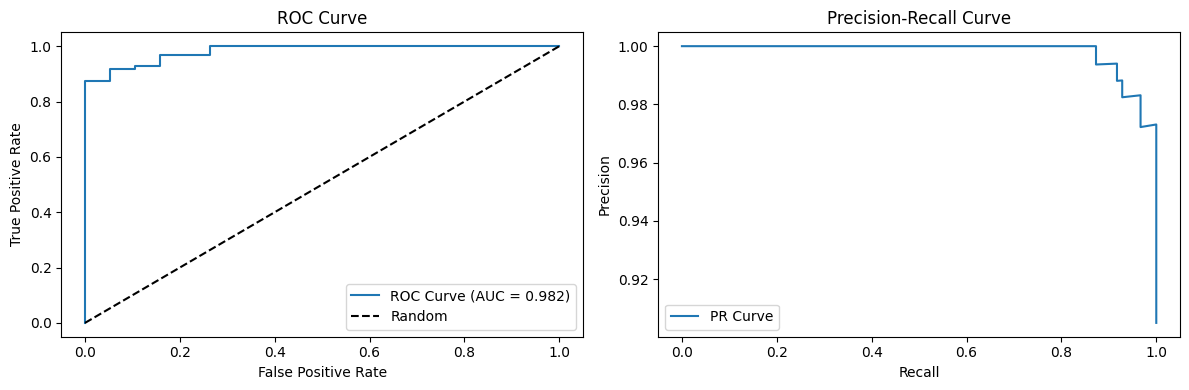


Prediction probability distribution:
Min probability: 0.0056
Max probability: 1.0000
Mean probability: 0.9165
Std probability: 0.2237


In [110]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

print("\n📊 MODEL INTERPRETATION")
print("="*25)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Plot Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label='PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

# Check prediction confidence distribution
print(f"\nPrediction probability distribution:")
print(f"Min probability: {y_test_proba.min():.4f}")
print(f"Max probability: {y_test_proba.max():.4f}")
print(f"Mean probability: {y_test_proba.mean():.4f}")
print(f"Std probability: {y_test_proba.std():.4f}")

**Analysis of the prediction probability distribution in five key points:**

- **Wide Probability Range:** The distribution spans from 0.0056 to 1.0000, indicating diverse confidence levels in predictions, from near-certain negatives to absolute positives.
- **High Mean Confidence:** A mean probability of 0.9165 suggests the model is generally highly confident, with most predictions leaning toward positive outcomes.
- **Moderate Variability:** The standard deviation of 0.2237 indicates moderate spread in prediction probabilities, reflecting some uncertainty in certain cases.
- **Skew Toward High Probabilities:** The high mean (0.9165) relative to the standard deviation suggests a skew toward higher probabilities, with fewer low-confidence predictions.
- **Potential Overconfidence:** The maximum probability of 1.0000 and high mean may indicate overconfidence in some predictions, warranting calibration checks to ensure reliability.

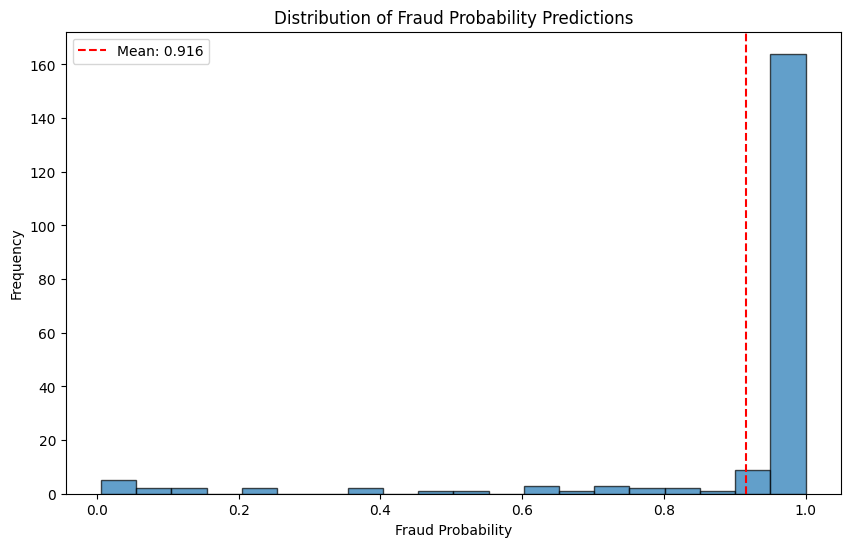

Fraud cases - Mean prob: 0.9767, Std: 0.0723
Legitimate cases - Mean prob: 0.3433, Std: 0.3375


In [50]:
# Check probability distribution in more detail
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(y_test_proba, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Fraud Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Fraud Probability Predictions')
plt.axvline(y_test_proba.mean(), color='red', linestyle='--', label=f'Mean: {y_test_proba.mean():.3f}')
plt.legend()
plt.show()

# Check how probabilities align with actual classes
fraud_probs = y_test_proba[y_test == 1]
legit_probs = y_test_proba[y_test == 0]

print(f"Fraud cases - Mean prob: {fraud_probs.mean():.4f}, Std: {fraud_probs.std():.4f}")
print(f"Legitimate cases - Mean prob: {legit_probs.mean():.4f}, Std: {legit_probs.std():.4f}")

**Analysis of the fraud and legitimate case probability results in five key points:**

- **High Fraud Confidence:** The mean probability for fraud cases (0.9767) indicates strong model confidence in identifying fraudulent activity, with predictions close to 1.
- **Low Fraud Variability:** The low standard deviation for fraud cases (0.0723) suggests consistent probability scores, implying reliable fraud detection across cases.
- **Lower Legitimate Confidence:** The mean probability for legitimate cases (0.3433) shows the model assigns moderate confidence to non-fraudulent cases, far from certainty.
- **High Legitimate Variability:** The high standard deviation for legitimate cases (0.3375) indicates significant variability in probability scores, suggesting inconsistency in classifying legitimate cases.
- **Class Separation:** The large gap between fraud (0.9767) and legitimate (0.3433) mean probabilities suggests good model discrimination, but high variance in legitimate cases may indicate potential misclassifications.